In [47]:
#  die einzelnen Zellen basieren 1:1 auf dem "Master-Notebook" zur Frage der Ukraine-Unterstützuung
# um das Risiko zu minimieren, die mit "ukraine" bezeichneten Variablen auf "bürgergeld" umzuändern, sind
# die variablen von der Bezeichnung her alle auf "ukraine" belassen, die untersuchten 'echten' Daten sind aber natürlich
# diejenigen, die das Bürgergeld betreffen

In [1]:
# Import von Bibliotheken
from datasets import load_dataset
import urllib.request
import io,re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
%pip install tqdm
from tqdm.notebook import tqdm
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


In [2]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
!pip install sentence-transformers
!pip install "transformers==4.47.1" "sentence-transformers"
from sentence_transformers import SentenceTransformer

In [3]:
# Einlesen der Langwahlprogramme (aus JSON-Format in ein Wörterbuch)

# für CDU/CSU
with open("cdu-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    CDU_text_json = json.load(datei)

# für SPD
with open("spd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    SPD_text_json = json.load(datei)

# für Die Linke
with open("linke-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Linke_text_json = json.load(datei)

# für die AfD
with open("afd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    AfD_text_json = json.load(datei)

# für Bündnis 90/Grüne
with open("gruene-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Grüne_text_json = json.load(datei)

# für FDP
with open("fdp-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    FDP_text_json = json.load(datei)

In [4]:
# Überführen aller 'eigentlichen' Texte in eine Liste pro Partei, d.h. ohne Kapitelüberschriften

# Suchfunktion in den "Partei-Wörterbüchern"

def finde_gefilterte_texte(struktur):
    ergebnisse = []
    
    # Fall A: Wenn das aktuelle Element ein Dictionary ist
    if isinstance(struktur, dict):
        # Typ/Art auslesen (liefert None, wenn der Schlüssel fehlt)
        aktueller_typ = struktur.get('type') or struktur.get('art')            # nur Suchen in diesen Elementen
        
        # Prüfen, ob 'text' existiert und der gefundene Typ gültig ist
        if 'text' in struktur and aktueller_typ in ['paragraph', 'bullet', 'absatz']:   # nur Texte überführen mit diesem Typ
            ergebnisse.append(struktur['text'])
        
        # Tiefer in alle Werte schauen für eventuelle Verschachtelungen
        for wert in struktur.values():
            ergebnisse.extend(finde_gefilterte_texte(wert))
                
    # Fall B: Wenn das aktuelle Element eine Liste ist
    elif isinstance(struktur, list):
        for element in struktur:
            ergebnisse.extend(finde_gefilterte_texte(element))
            
    return ergebnisse

CDU_text = finde_gefilterte_texte(CDU_text_json)
CDU_text = CDU_text[135:]   # da vor der eigentlichen Langfassung im CDU/CSU-Programm noch eine Kurzfassung vorangeht, wird diese ausgeblendet
SPD_text = finde_gefilterte_texte(SPD_text_json)
Linke_text = finde_gefilterte_texte(Linke_text_json)
Grüne_text = finde_gefilterte_texte(Grüne_text_json)
AfD_text = finde_gefilterte_texte(AfD_text_json)
FDP_text = finde_gefilterte_texte(FDP_text_json)

In [5]:
# Bereinigen der Texte => Umformen von Abkürzungen in Text um Eindruck von einem Satzende zu vermeiden

def bereinige_abkuerzungen(text):
    # Dictionary mit den Top 20 Ersetzungen (Regex-Muster als Key)
    ersetzungen = {
        r'\bz\.\s*B\.': 'zum Beispiel',   # r'\bz\.\s*B\.\b': 'zum Beispiel',
        r'\bu\.\s*a\.': 'unter anderem',
        r'\bd\.\s*h\.': 'das heißt',
        r'\bbzw\.': 'beziehungsweise',
        r'\bbzw': 'beziehungsweise',   # Variante ohne Punkt
        r'\bsog\.': 'sogenannte',
        r'\bca\.': 'circa',
        r'\bevtl\.': 'eventuell',
        r'\binkl\.': 'inklusive',
        r'\betc\.': 'et cetera',
        r'\bvgl\.': 'vergleiche',
        r'\bs\.': 'siehe',
        r'\bu\.\s*v\.\s*m\.': 'und vieles mehr',
        r'\bu\.\s*ä\.': 'und ähnliche',
        r'\bggf\.': 'gegebenenfalls',
        r'\bzzgl\.': 'zuzüglich',
        r'\bebd\.': 'ebenda',
        r'\bo\.\s*g\.': 'oben genannte',
        r'\bu\.\s*g\.': 'unten genannte',
        r'\bi\.\s*d\.\s*R\.': 'in der Regel',
        r'\bv\.\s*a\.': 'vor allem',

        # 2. Titel & Personen (Verhindern Satzabbruch mitten im Fluss)
        r'\bDr\.': 'Doktor',
        r'\bProf\.': 'Professor',
        r'\bFr\.': 'Frau',
        r'\bHr\.': 'Herr',

        # 3. Wortlaengen- & Silben-Verfaelscher
        r'\bbspw\.': 'beispielsweise',
        r'\bbspw': 'beispielsweise',   # Variante ohne Punkt
        r'\bbsp\.': 'Beispiel',
        r'\bJh\.': 'Jahrhundert',
        r'\bMio\.': 'Millionen',
        r'\bMrd\.': 'Milliarden',
        r'\bbetr\.': 'betreffend',
        r'\bbezgl\.': 'bezüglich',
        r'\bvs\.': 'versus'
    }

    # Text Schritt für Schritt bereinigen
    for muster, ersetzung in ersetzungen.items():
        # flags=re.IGNORECASE sorgt dafür, dass auch "Z.B." oder "Bzw." gefunden werden
        text = re.sub(muster, ersetzung, text, flags=re.IGNORECASE)

    return text

In [6]:
CDU_text = [bereinige_abkuerzungen(text) for text in CDU_text]
SPD_text = [bereinige_abkuerzungen(text) for text in SPD_text]
Grüne_text = [bereinige_abkuerzungen(text) for text in Grüne_text]
AfD_text = [bereinige_abkuerzungen(text) for text in AfD_text]
Linke_text = [bereinige_abkuerzungen(text) for text in Linke_text]
FDP_text = [bereinige_abkuerzungen(text) for text in FDP_text]

In [7]:
# Bereinigung der Wahlprogramme-Texte analog Kapitel 5

# für die FDP
FDP_text = [text for text in FDP_text if len(text) >= 60]
# für die SPD
loesch_indizes = {1, 8, 11, 13, 22, 33, 34, 35, 52}
SPD_text = [element for index, element in enumerate(SPD_text) if index not in loesch_indizes]
# für die Grüne
loesch_indizes = {8, 10, 13, 16, 23, 24}
Grüne_text = [element for index, element in enumerate(Grüne_text) if index not in loesch_indizes]
# für die Linke
loesch_indizes = {13, 75, 93, 101, 104, 106, 115}
Linke_text = [element for index, element in enumerate(Linke_text) if index not in loesch_indizes]
# für die AfD
loesch_indizes = {0,}
AfD_text = [element for index, element in enumerate(AfD_text) if index not in loesch_indizes]
# für die CDU/CSU
CDU_text = [text for text in CDU_text if len(text) >= 89]

In [8]:
import json
import urllib.request, urllib.parse, urllib.error
stammdaten = ("MDB_STAMMDATEN.XML")  # mit den Parteizugehörigkeiten
from bs4 import BeautifulSoup
with open(stammdaten, "r", encoding="utf-8") as f:
  	soup2 = BeautifulSoup(f, "xml")

redner_id_mdb = dict()
for mdb in soup2.find_all("MDB"):
	id_tag = mdb.find("ID")
	party_tag = mdb.find("PARTEI_KURZ")
	mdb_id = id_tag.text if id_tag else None
	party = party_tag.text if party_tag else None
	redner_id_mdb[mdb_id] = party

# da wo keine Parteizugehörigkeit aus den Stammdaten ersichtlich, manuelles Hinzufügen diverser Nummern
redner_id_mdb["11002735"]  # MERZ
redner_id_mdb["999990151"] = "SPD"
redner_id_mdb["999990133"] = "SPD"
redner_id_mdb["999990074"] = "SPD"
redner_id_mdb["11005217 999990074"] = "SPD"
redner_id_mdb["999990119"] = "SPD"
redner_id_mdb["999990149"] = "SPD"
redner_id_mdb["999990080"] = "parteilos"
redner_id_mdb["999990142"] = "parteilos"
redner_id_mdb["999990154"] = "parteilos"
redner_id_mdb["999990152"] = "CDU"
redner_id_mdb["999990153"] = "CDU"
redner_id_mdb["999990150"] = "CDU"
redner_id_mdb["999990141"] = "CSU"
redner_id_mdb["999990193"] = "SPD"
redner_id_mdb["999990093"] = "SPD"
redner_id_mdb["999990120"] = "SPD"
redner_id_mdb["999990129"] = "SPD"
redner_id_mdb["999990145"] = "SPD"
redner_id_mdb["999990144"] = "CDU"
redner_id_mdb["999990125"] = "CDU"
redner_id_mdb["999990147"] = "CSU"
redner_id_mdb["999990146"] = "SPD"
redner_id_mdb["999990121"] = "SPD"
redner_id_mdb["999990148"] = "SPD"
redner_id_mdb["999990122"] = "BÜNDNIS 90/DIE GRÜNEN"
redner_id_mdb["999990123"] = "DIE LINKE"
redner_id_mdb["999990148"] = "SPD"
redner_id_mdb["999990122"] = "BÜNDNIS 90/DIE GRÜNEN"
redner_id_mdb["999990123"] = "DIE LINKE"
redner_id_mdb["999990124"] = "SPD"
redner_id_mdb["999990078"] = "FDP"
redner_id_mdb["999990082"] = "SPD"

In [9]:
# Import der Bundestagsreden via gültigem API-Key für die 5 Betrachtungszeiträume
# API-Key gültig bis zunächst Ende Mai 2027
api = "R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ"

# Eingrenzung Zeitraum Nr. 1, Umwandlung in json-Format & Extraktion der XML-URLs (=Protokolle) aus dem Dictionary
html_zeitraum_1 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2022-01-01&f.datum.end=2022-03-31&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_1 = json.loads(html_zeitraum_1)
# Erfassen der XML-URLs in einer Liste
data_zeitraum_1_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_1["documents"]
    if "xml_url" in doc["fundstelle"]
]   # 17 Protokolle

# Eingrenzung Zeitraum Nr. 2...
html_zeitraum_2 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2023-10-01&f.datum.end=2023-12-31&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_2 = json.loads(html_zeitraum_2)
data_zeitraum_2_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_2["documents"]
    if "xml_url" in doc["fundstelle"]
]  # 19 Protokolle

# Eingrenzung Zeitraum Nr. 3...
html_zeitraum_3 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2024-10-01&f.datum.end=2024-12-31&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_3 = json.loads(html_zeitraum_3)
data_zeitraum_3_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_3["documents"]
    if "xml_url" in doc["fundstelle"]
]   # 19 Protokolle

# Eingrenzung Zeitraum Nr. 4...
html_zeitraum_4 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2025-01-01&f.datum.end=2025-02-23&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_4 = json.loads(html_zeitraum_4)
data_zeitraum_4_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_4["documents"]
    if "xml_url" in doc["fundstelle"]
]    # 4 Protokolle

# Eingrenzung Zeitraum Nr. 5...
html_zeitraum_5 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2025-05-01&f.datum.end=2025-07-31&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_5 = json.loads(html_zeitraum_5)
data_zeitraum_5_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_5["documents"]
    if "xml_url" in doc["fundstelle"]   
]    # 18 Protokolle

In [10]:
# Anzahl Reden pro Partei und Zeitraum
# zunächst leere Listen
text_liste_CDU_1 = []
text_liste_CDU_2 = []
text_liste_CDU_3 = []
text_liste_CDU_4 = []
text_liste_CDU_5 = []

text_liste_SPD_1 = []
text_liste_SPD_2 = []
text_liste_SPD_3 = []
text_liste_SPD_4 = []
text_liste_SPD_5 = []

text_liste_FDP_1 = []
text_liste_FDP_2 = []
text_liste_FDP_3 = []
text_liste_FDP_4 = []
text_liste_FDP_5 = []

text_liste_Grüne_1 = []
text_liste_Grüne_2 = []
text_liste_Grüne_3 = []
text_liste_Grüne_4 = []
text_liste_Grüne_5 = []

text_liste_Linke_1 = []
text_liste_Linke_2 = []
text_liste_Linke_3 = []
text_liste_Linke_4 = []
text_liste_Linke_5 = []

text_liste_AfD_1 = []
text_liste_AfD_2 = []
text_liste_AfD_3 = []
text_liste_AfD_4 = []
text_liste_AfD_5 = []

# Durchlauf aller extrahierter XML-URLs pro Zeitraum (1 bis 5), Anhängen der Reden pro Partei und Zeitraum an die obigen Listen
for i in data_zeitraum_1_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_1.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_1.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_1.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_1.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_1.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_1.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_1.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_1.append(p)

for i in data_zeitraum_2_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_2.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_2.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_2.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_2.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_2.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_2.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_2.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_2.append(p)

for i in data_zeitraum_3_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_3.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_3.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_3.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_3.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_3.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_3.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_3.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_3.append(p)

for i in data_zeitraum_4_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_4.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_4.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_4.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_4.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_4.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_4.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_4.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_4.append(p)

for i in data_zeitraum_5_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_5.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_5.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_5.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_5.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_5.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_5.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_5.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_5.append(p)

In [11]:
def bereinige_text_liste(liste):
    bereinigte_liste = []
    for i in liste:

        # Metadaten
        i = str(i[1:]).replace('<p klasse="J_1">', "")
        i = i.replace('<p klasse="J">', "")
        i = i.replace('<p klasse="O">', "")
        i = i.replace("<p klasse=", "")
        i = re.sub(r'-\s+', '', i)
        i = re.sub(r'[^\w\s\.!\?€,,:\(\)\-%]', '', i)

        # Sonstiges
        i = i.replace("p, ", " ")
        i = i.replace(".p, p", ".")
        i = i.replace(":p, ",": ")
        i = i.replace("nachnamefraktion", "")
        i = i.replace("fraktionnameredner", "")
        i = re.sub(r'\b(?:sup1sup|3apfussnote)\w*\s?', '', i)   # Fußnoten

        # Texte der Bundestagspräsidentin, die im eigentlichen Redetext zu finden waren
        i = re.sub(r".*?hat als Nächstes das Wort für.*?\.", "", i)
        i = re.sub(r'Das\s+Wort\s+hat\s+nun\s+für\s+die\s+Fraktion\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'Ich\s+erteile\s+das\s+Wort\s+als\s+Nächstes\s+[\w\s. -ÄÖÜäöüß]+[\.!?]', '', i)
        i = re.sub(r'Für\s+die\s+Fraktion\s+[\w\s.-]+\s+hat\s+nun\s+das\s+Wort\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'Für die (?:\w+)-Fraktion hat das Wort d(?:ie Kollegin|er Kollege)\s+([^.]+)\.?', '', i) # 
        i = re.sub(r'Für\s+die\s+Fraktion\s+[\w\s.-]+\s+spricht\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'Für\s+die\s+[\w\s.-]+\s+hat\s+nun\s+[\w\s.-]+\s+das\s+Wort[\.!?]', '', i)
        i = re.sub(r'^[A-Z][a-zßäöü]+ [A-Z][a-zßäöü]+, kommen Sie bitte zu Ihrer Rede\.', '', i)
        i = re.sub(r"Das Wort für .*? hat .*?\.", "", i)
        i = i.replace("Kommen Sie bitte zum Ende Ihrer Rede.", "")
        i = i.replace("Kommen Sie bitte zum Ende. ", "")
        i = i.replace("Es ist ihre erste Rede.", "")
        i = re.sub(r'rednerredner\s+id\d+[\w\s.-]*:', '', i)
        i = i.replace(", kommen Sie bitte zum Ende Ihrer Rede.p", "")
        i = i.replace(", kommen Sie bitte zum Schluss.", "")
        i = i.replace(", kommen Sie bitte zu Ihrer Rede.", "")
        i = i.replace("Sehr geehrter Herr Botschafter, ", "")
        i = i.replace("Kommen Sie zum Schluss.", "")
        i = re.sub(r'Die\s+nächste\s+Rednerin\s+ist\s+[\w\s.-]+\s+für\s+die\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'Der\s+nächste\s+Redner\s+ist\s+[\w\s.-]+\s+für\s+die\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'[D|d]er nächste Redner in der Debatte ist [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)? [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)?\.?', '', i)
        i = re.sub(r'[D|d]ie nächste Rednerin in der Debatte ist [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)? [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)?\.?', '', i)
        i = re.sub(r'rednerredner\s+[\w\s. -ÄÖÜäöüß]+:', '', i)
        i = re.sub(r'[F|f]ür die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+-Fraktion erhält das Wort [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?)?\.?', '', i)
        i = re.sub(r'Als\s+Nächstes\s+spricht\s+[\w\s. -ÄÖÜäöüß]+[\.!?]', '', i)
        i = re.sub(r'Als Letzte[r]? in der Aktuellen Stunde hat das Wort d(?:ie Kollegin|er Kollege)\s+([^.]+)\.?', '', i)
        i = re.sub(r'[I|i]ch darf für die Fraktion (?:[A-Zßäöüa-z\s\/äöü]+) [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)? [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)? aufrufen\.?', '', i)
        i = re.sub(r'[I|i]ch erteile das Wort für die nächste Rede (?:[A-ZßäöüÄÖÜa-z\s\/äöü]+) [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?)?\.?', '', i)
        i = re.sub(r'[I|i]ch erteile als Nächstes das Wort de[mr] Abgeordneten [A-Z][a-zßäöüÄÖÜ]+(?: [A-Z][a-zßäöüÄÖÜ]+)* für die [A-Za-zßäöüÄÖÜ\s\/]+(?:\.)?', '', i)
        i = re.sub(r'[D|d]ie nächste Rede hält [A-Z][a-zßäöüÄÖÜ]+(?: [A-Z][a-zßäöüÄÖÜ]+)* für die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'[I|i]ch darf aufrufen für die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'[D|d]ie nächste Rede hält [A-Z][a-zßäöüÄÖÜ]+(?: [A-Z][a-zßäöüÄÖÜ]+)*(?:\.)?', '', i)
        i = re.sub(r'[A[Aa]ls nächste(?:r)? (?:Rednerin|Redner) hat [A-ZßäöüÄÖÜa-z\s\-\/\.]+ das Wort\.?', '', i)
        i = re.sub(r'[E[Ee]benfalls zur ersten Rede erteile ich das Wort [A-ZßäöüÄÖÜa-z\s\-\/\.]+\.?', '', i)
        i = re.sub(r'[Ii]ch darf [A-ZßäöüÄÖÜa-z\s\-\/\.]+ das Wort erteilen\.?', '', i)
        i = re.sub(r'[Ii]ch darf [A-ZßäöüÄÖÜa-z\s\-\/\.]+ aufrufen\.?', '', i)
        i = re.sub(r'[Ii]ch erteile das Wort [A-ZßäöüÄÖÜa-z\s\-\/\.]+\.?', '', i)
        i = re.sub(r'[Vv]ielen Dank und Gratulation zu Ihrer ersten Rede, (?:Frau|Herr) [A-ZßäöüÄÖÜa-z\s\-\/\.]+(?:\.)?', '', i)
        i = re.sub(r'[Ff]ür die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+ das Wort zu seiner ersten Rede\.', '', i)
        i = re.sub(r'[Ff]ür die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+ das Wort zu ihrer ersten Rede\.', '', i)
        i = re.sub(r'[Dd]er nächste Redner in der Debatte: für [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'(Der|Die) nächste Redner(?:in)? ist [^.]+(?:\.)?', '', i)  #
        i = re.sub(r'[Dd]ie nächste Rednerin in der Debatte: für [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'[Dd]ann rufe ich [A-ZßäöüÄÖÜa-z\s\-\/\.]+ in der Debatte auf: [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+)? für [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'[Zz]u (?:seiner|ihrer) ersten Rede hat nun [A-ZßäöüÄÖÜa-z\s\-\/\.]+ das Wort\.?', '', i)
        i = re.sub(r'von der [A-Za-zßäöüÄÖÜ\s\-\/0-9]+, für (?:den|die) es hier die erste Rede ist\.?', '', i)
        i = i.replace("Das Wort hat nun für die Fraktion ", "")
        i = i.replace("Ich erteile das Wort als Nächstes ", "")
        i = re.sub(r'[Aa]ls [Nn]ächste(?:r)? hat (?:das Wort )?[\w\s.\-ÄÖÜäöüß0-9/]+?\s*[.!?]+(\s*|$)', '', i)

        # letzte Bereinigungen
        i = i.removesuffix('p')
        i = re.sub(r"\s+", " ", i)
        i = re.sub(r"id\d+\S*", " ", i)
        i = i.replace("\xa0", "")
        i = i.replace("</p>", "")
        i = i.replace("</p", "")
        i = i.replace("p, p, ", "")
        i = i.lstrip()
        i = i.rstrip(" ")
        i = i.replace("redner ", "")
        i = i.replace("vorname", "")
        i = re.sub(r"vorname(.*?)vorname", " ", i)
        i = re.sub(r"nachname(.*?)nachname", " ", i)
        i = re.sub(r"fraktion(.*?)fraktion", " ", i)
        i = i.replace("nachname fraktion", "")
        i = i.replace("rolle rolle_langBundesminister", "")
        i = i.replace("rolle_kurzBundesminister für ", "")
        i = i.replace("Bundesministerin des Innern und für Heimat", "")
        i = i.replace("Bundesministerin BMI", "")
        i = i.replace("rolle_kurz", "")
        i = i.replace("(CDUCSU)", "")
        i = i.replace("(SPD)", "")
        bereinigte_liste.append(i)
    return bereinigte_liste

# Zeitraum 1
text_liste_CDU_1_clean = bereinige_text_liste(text_liste_CDU_1)
text_liste_SPD_1_clean = bereinige_text_liste(text_liste_SPD_1)
text_liste_Linke_1_clean = bereinige_text_liste(text_liste_Linke_1)
text_liste_AfD_1_clean = bereinige_text_liste(text_liste_AfD_1)
text_liste_Grüne_1_clean = bereinige_text_liste(text_liste_Grüne_1)
text_liste_FDP_1_clean = bereinige_text_liste(text_liste_FDP_1)

# Zeitraum 2
text_liste_CDU_2_clean = bereinige_text_liste(text_liste_CDU_2)
text_liste_SPD_2_clean = bereinige_text_liste(text_liste_SPD_2)
text_liste_Linke_2_clean = bereinige_text_liste(text_liste_Linke_2)
text_liste_AfD_2_clean = bereinige_text_liste(text_liste_AfD_2)
text_liste_Grüne_2_clean = bereinige_text_liste(text_liste_Grüne_2)
text_liste_FDP_2_clean = bereinige_text_liste(text_liste_FDP_2)

# Zeitraum 3
text_liste_CDU_3_clean = bereinige_text_liste(text_liste_CDU_3)
text_liste_SPD_3_clean = bereinige_text_liste(text_liste_SPD_3)
text_liste_Linke_3_clean = bereinige_text_liste(text_liste_Linke_3)
text_liste_AfD_3_clean = bereinige_text_liste(text_liste_AfD_3)
text_liste_Grüne_3_clean = bereinige_text_liste(text_liste_Grüne_3)
text_liste_FDP_3_clean = bereinige_text_liste(text_liste_FDP_3)

# Zeitraum 4
text_liste_CDU_4_clean = bereinige_text_liste(text_liste_CDU_4)
text_liste_SPD_4_clean = bereinige_text_liste(text_liste_SPD_4)
text_liste_Linke_4_clean = bereinige_text_liste(text_liste_Linke_4)
text_liste_AfD_4_clean = bereinige_text_liste(text_liste_AfD_4)
text_liste_Grüne_4_clean = bereinige_text_liste(text_liste_Grüne_4)
text_liste_FDP_4_clean = bereinige_text_liste(text_liste_FDP_4)

# Zeitraum 5
text_liste_CDU_5_clean = bereinige_text_liste(text_liste_CDU_5)
text_liste_SPD_5_clean = bereinige_text_liste(text_liste_SPD_5)
text_liste_Linke_5_clean = bereinige_text_liste(text_liste_Linke_5)
text_liste_AfD_5_clean = bereinige_text_liste(text_liste_AfD_5)
text_liste_Grüne_5_clean = bereinige_text_liste(text_liste_Grüne_5)
text_liste_FDP_5_clean = bereinige_text_liste(text_liste_FDP_5)

In [12]:
# Als JSON speichern
with open("text_liste_CDU_1_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_CDU_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_CDU_2_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_CDU_2_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_CDU_3_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_CDU_3_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_CDU_4_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_CDU_4_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_CDU_5_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_CDU_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_CDU_5_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_CDU_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_SPD_1_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_SPD_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_SPD_2_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_SPD_2_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_SPD_3_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_SPD_3_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_SPD_4_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_SPD_4_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_SPD_5_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_SPD_5_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Linke_1_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Linke_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Linke_2_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Linke_2_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Linke_3_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Linke_3_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Linke_4_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Linke_4_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Linke_5_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Linke_5_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Grüne_1_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Grüne_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Grüne_2_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Grüne_2_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Grüne_3_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Grüne_3_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Grüne_4_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Grüne_4_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_Grüne_5_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_Grüne_5_clean, f, ensure_ascii=False, indent=4)
    
with open("text_liste_AfD_1_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_AfD_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_AfD_2_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_AfD_2_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_AfD_3_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_AfD_3_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_AfD_4_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_AfD_4_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_AfD_5_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_AfD_5_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_FDP_1_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_FDP_1_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_FDP_2_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_FDP_2_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_FDP_3_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_FDP_3_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_FDP_4_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_FDP_4_clean, f, ensure_ascii=False, indent=4)

with open("text_liste_FDP_5_kap6.json", "w", encoding="utf-8") as f:
    json.dump(text_liste_FDP_5_clean, f, ensure_ascii=False, indent=4)

In [13]:
# TESTDRUCK
print(len(text_liste_Linke_4_clean))
print(len(text_liste_Linke_4_clean[0]))
print(len(text_liste_Linke_5_clean))
print(len(text_liste_Linke_5_clean[0]))
print(text_liste_Linke_4_clean[0][:1000])

24
9747
218
4541
Sehr geehrte Frau Präsidentin! Liebe Kolleginnen und Kollegen! Es ist ganz spannend, wenn man, wie meine Partei, an Hunderttausenden Haustüren klingelt, mit den Leuten spricht und vor allem zuhört. Dann stellt man nämlich fest: Ganz oft sind es die sozialen Fragen, die die Leute umtreiben: Wie komme ich über die Runden? Kann ich mir mein Leben noch leisten? Muss ich wegziehen, weil die Mieten immer weiter erhöht werden? Vor allem: Wo finde ich überhaupt noch eine bezahlbare Wohnung? Heute geht es ja eigentlich um die Bilanz der Ampel, und beim Thema Mieten ist die katastrophal. Dabei hat Olaf Scholz bei der letzten Wahl noch plakatiert, er sei der Kanzler für bezahlbares Wohnen. Aber nicht mal die zahnlose Mietpreisbremse haben Sie verlängert. Der Plan, 400 000 Wohnungen pro Jahr zu bauen 100 000 davon sozial gebunden , ist krachend gescheitert. Die Mieten sind auf neuem Höchstniveau. Und wir sehen jeden Tag, wozu das führt: Rentner-innen müssen ihr soziales Umfeld ver

In [14]:
!pip install langchain_text_splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

def split_text(text):
    # chunk_size: Maximale Zeichenanzahl pro Abschnitt
    # chunk_overlap: Wie viele Zeichen vom vorherigen Abschnitt wiederholt werden
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=3600, # viel länger als in Kapitel 5 mit 800 chunks, um Semantik abzufangen
        chunk_overlap=400,
        separators = ["\n\n", "\n", ". ", "? ", "! ", " ", ""] # Sucht erst nach Absätzen, dann Sätzen, dann Wörtern
    )

    # Gibt eine Liste von Strings zurück
    return splitter.split_text(text)

In [15]:
# Wahlprogramme nicht in chunks aufteilen; Annahme: Absätze behandeln i.d.R. ein Thema
CDU_WP_chunks = CDU_text
SPD_WP_chunks = SPD_text
Grüne_WP_chunks = Grüne_text
AfD_WP_chunks = AfD_text
Linke_WP_chunks = Linke_text
FDP_WP_chunks = FDP_text

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_WP_chunks_len = len(CDU_WP_chunks)
SPD_WP_chunks_len = len(SPD_WP_chunks)
Grüne_WP_chunks_len = len(Grüne_WP_chunks)
AfD_WP_chunks_len = len(AfD_WP_chunks)
Linke_WP_chunks_len = len(Linke_WP_chunks)
FDP_WP_chunks_len = len(FDP_WP_chunks)

# Bundestagsreden in chunks aufteilen von 4800 Zeichen, ohne chunk_overlap

CDU_1_chunks = [chunk for rede in text_liste_CDU_1_clean for chunk in split_text(rede)]
CDU_2_chunks = [chunk for rede in text_liste_CDU_2_clean for chunk in split_text(rede)]
CDU_3_chunks = [chunk for rede in text_liste_CDU_3_clean for chunk in split_text(rede)]
CDU_4_chunks = [chunk for rede in text_liste_CDU_4_clean for chunk in split_text(rede)]
CDU_5_chunks = [chunk for rede in text_liste_CDU_5_clean for chunk in split_text(rede)]

SPD_1_chunks = [chunk for rede in text_liste_SPD_1_clean for chunk in split_text(rede)]
SPD_2_chunks = [chunk for rede in text_liste_SPD_2_clean for chunk in split_text(rede)]
SPD_3_chunks = [chunk for rede in text_liste_SPD_3_clean for chunk in split_text(rede)]
SPD_4_chunks = [chunk for rede in text_liste_SPD_4_clean for chunk in split_text(rede)]
SPD_5_chunks = [chunk for rede in text_liste_SPD_5_clean for chunk in split_text(rede)]

Linke_1_chunks = [chunk for rede in text_liste_Linke_1_clean for chunk in split_text(rede)]
Linke_2_chunks = [chunk for rede in text_liste_Linke_2_clean for chunk in split_text(rede)]
Linke_3_chunks = [chunk for rede in text_liste_Linke_3_clean for chunk in split_text(rede)]
Linke_4_chunks = [chunk for rede in text_liste_Linke_4_clean for chunk in split_text(rede)]
Linke_5_chunks = [chunk for rede in text_liste_Linke_5_clean for chunk in split_text(rede)]

Grüne_1_chunks = [chunk for rede in text_liste_Grüne_1_clean for chunk in split_text(rede)]
Grüne_2_chunks = [chunk for rede in text_liste_Grüne_2_clean for chunk in split_text(rede)]
Grüne_3_chunks = [chunk for rede in text_liste_Grüne_3_clean for chunk in split_text(rede)]
Grüne_4_chunks = [chunk for rede in text_liste_Grüne_4_clean for chunk in split_text(rede)]
Grüne_5_chunks = [chunk for rede in text_liste_Grüne_5_clean for chunk in split_text(rede)]

AfD_1_chunks = [chunk for rede in text_liste_AfD_1_clean for chunk in split_text(rede)]
AfD_2_chunks = [chunk for rede in text_liste_AfD_2_clean for chunk in split_text(rede)]
AfD_3_chunks = [chunk for rede in text_liste_AfD_3_clean for chunk in split_text(rede)]
AfD_4_chunks = [chunk for rede in text_liste_AfD_4_clean for chunk in split_text(rede)]
AfD_5_chunks = [chunk for rede in text_liste_AfD_5_clean for chunk in split_text(rede)]

FDP_1_chunks = [chunk for rede in text_liste_FDP_1_clean for chunk in split_text(rede)]
FDP_2_chunks = [chunk for rede in text_liste_FDP_2_clean for chunk in split_text(rede)]
FDP_3_chunks = [chunk for rede in text_liste_FDP_3_clean for chunk in split_text(rede)]
FDP_4_chunks = [chunk for rede in text_liste_FDP_4_clean for chunk in split_text(rede)]

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_1_chunks_len = len(CDU_1_chunks)
CDU_2_chunks_len = len(CDU_2_chunks)
CDU_3_chunks_len = len(CDU_3_chunks)
CDU_4_chunks_len = len(CDU_4_chunks)
CDU_5_chunks_len = len(CDU_5_chunks)

SPD_1_chunks_len = len(SPD_1_chunks)
SPD_2_chunks_len = len(SPD_2_chunks)
SPD_3_chunks_len = len(SPD_3_chunks)
SPD_4_chunks_len = len(SPD_4_chunks)
SPD_5_chunks_len = len(SPD_5_chunks)

Grüne_1_chunks_len = len(Grüne_1_chunks)
Grüne_2_chunks_len = len(Grüne_2_chunks)
Grüne_3_chunks_len = len(Grüne_3_chunks)
Grüne_4_chunks_len = len(Grüne_4_chunks)
Grüne_5_chunks_len = len(Grüne_5_chunks)

Linke_1_chunks_len = len(Linke_1_chunks)
Linke_2_chunks_len = len(Linke_2_chunks)
Linke_3_chunks_len = len(Linke_3_chunks)
Linke_4_chunks_len = len(Linke_4_chunks)
Linke_5_chunks_len = len(Linke_5_chunks)

AfD_1_chunks_len = len(AfD_1_chunks)
AfD_2_chunks_len = len(AfD_2_chunks)
AfD_3_chunks_len = len(AfD_3_chunks)
AfD_4_chunks_len = len(AfD_4_chunks)
AfD_5_chunks_len = len(AfD_5_chunks)

FDP_1_chunks_len = len(FDP_1_chunks)
FDP_2_chunks_len = len(FDP_2_chunks)
FDP_3_chunks_len = len(FDP_3_chunks)
FDP_4_chunks_len = len(FDP_4_chunks)

# 1. Chunks aller Parteien kombinieren
alle_chunks = (CDU_WP_chunks + CDU_1_chunks + CDU_2_chunks + CDU_3_chunks + CDU_4_chunks + CDU_5_chunks +
SPD_WP_chunks + SPD_1_chunks + SPD_2_chunks + SPD_3_chunks + SPD_4_chunks + SPD_5_chunks +
Grüne_WP_chunks + Grüne_1_chunks + Grüne_2_chunks + Grüne_3_chunks + Grüne_4_chunks + Grüne_5_chunks +
AfD_WP_chunks + AfD_1_chunks + AfD_2_chunks + AfD_3_chunks + AfD_4_chunks + AfD_5_chunks +
Linke_WP_chunks + Linke_1_chunks + Linke_2_chunks + Linke_3_chunks + Linke_4_chunks + Linke_5_chunks +
FDP_WP_chunks + FDP_1_chunks + FDP_2_chunks + FDP_3_chunks + FDP_4_chunks)

# Parteilabels

partei_labels = (
    ["CDU/CSU"] * CDU_WP_chunks_len + ["CDU/CSU"] * CDU_1_chunks_len + ["CDU/CSU"] * CDU_2_chunks_len + ["CDU/CSU"] * CDU_3_chunks_len + ["CDU/CSU"] * CDU_4_chunks_len + ["CDU/CSU"] * CDU_5_chunks_len +
    ["SPD"] * SPD_WP_chunks_len + ["SPD"] * SPD_1_chunks_len + ["SPD"] * SPD_2_chunks_len + ["SPD"] * SPD_3_chunks_len + ["SPD"] * SPD_4_chunks_len + ["SPD"] * SPD_5_chunks_len +
    ["Grüne"] * Grüne_WP_chunks_len + ["Grüne"] * Grüne_1_chunks_len + ["Grüne"] * Grüne_2_chunks_len + ["Grüne"] * Grüne_3_chunks_len + ["Grüne"] * Grüne_4_chunks_len + ["Grüne"] * Grüne_5_chunks_len +
    ["AfD"] * AfD_WP_chunks_len + ["AfD"] * AfD_1_chunks_len + ["AfD"] * AfD_2_chunks_len + ["AfD"] * AfD_3_chunks_len + ["AfD"] * AfD_4_chunks_len + ["AfD"] * AfD_5_chunks_len +
    ["Linke"] * Linke_WP_chunks_len + ["Linke"] * Linke_1_chunks_len + ["Linke"] * Linke_2_chunks_len + ["Linke"] * Linke_3_chunks_len + ["Linke"] * Linke_4_chunks_len + ["Linke"] * Linke_5_chunks_len +
    ["FDP"] * FDP_WP_chunks_len + ["FDP"] * FDP_1_chunks_len + ["FDP"] * FDP_2_chunks_len + ["FDP"] * FDP_3_chunks_len + ["FDP"] * FDP_4_chunks_len
)

In [16]:
print("Anzahl aller Chunks: ",len(alle_chunks))

Anzahl aller Chunks:  16039


In [17]:
print("Anzahl aller Partei-Labels: ",len(partei_labels))

Anzahl aller Partei-Labels:  16039


In [18]:
seed_dict_keys = {
    0: "Innere Sicherheit",
    1: "Asyl- und Zuwanderungspolitik",
    2: "Gesellschafts- und Familienpolitik",
    3: "Verkehrs- und Infrastrukturpolitik",
    4: "Wohnungsmarktpolitik",
    5: "Gesundheitspolitik",
    6: "Bildungspolitik",
    7: "Wirtschaft und Finanzen",
    8: "Digitalisierung & Verwaltung",
    9: "Außen-, Europa- und Verteidigungspolitik",
    10: "Arbeitsmarktpolitik",
    11: "Sozial- und Rentenpolitik",
    12: "Umweltpolitik"
}

topic_names = list(seed_dict_keys.values())

seed_topic_list = [

    # 0 Innere Sicherheit
    ['innenminister', 'bundespolizei', 'bundeskriminalamt', 'verfassungsschutz', 'kriminalitätsbekämpfung', 'kriminalstatistik', 'messerverbot', 'vorratsdatenspeicherung', 'kriminalität', 'clankriminalität', 'gewaltkriminalität', 'organisierte Kriminalität', 'messer', 'körperverletzung', 'gewalttäter', 'straftat', 'gefährder', 'waffenrecht', 'extremisten'],

    # 1 Asyl und Zuwanderung
    ['asylverfahren', 'irreguläre migration', 'migration', 'rückführung', 'geflüchtete', 'integration', 'grenzschutz', 'abschiebung', 'massenmigration', 'migrationshintergrund', 'migrationströme', 'migrationspolitik', 'integrationsfähigkeit', 'islamismus', 'islam', 'remigration', 'muslime', 'migrationsdebatte', 'fluchtumlage', 'fluchtursache'],

    # 2 Gesellschaft und Familie
    ['frauenquote', 'gender', 'diskriminierung', 'selbstbestimmungsgesetz', 'entgeltgleichheit', 'elterngeld', 'familienförderung', 'kindergrundsicherung', 'kindergeld', 'elternzeit', 'gendern', 'gendergerechtigkeit', 'familienpolitik', 'kinderrechte', 'kinder', 'mütter', 'väter', 'jugendschutz', 'elternrechte'],

    # 3 Verkehr und Infrastruktur
    ['brückensanierung', 'schienennetz', 'deutsche bahn', 'deutschlandticket', 'radwege', 'straßenbau', 'e-mobilität', 'verkehrswende', 'fernverkehr', 'brücken', 'flughafen', 'hafen', 'logistik', 'straßen', 'bahnstrecke', 'güterverkehr', 'wasserstraßen', 'fußwege'],

    # 4 Wohnungsmarkt
    ['grundsteuer', 'mietpreisbremse', 'wohngeld', 'sozialer wohnungsbau', 'wohnungsbau', 'immobilienmarkt', 'baugenehmigung', 'heizungsgesetz', 'immobilie', 'bestandsimmobilie', 'wohnungsbauvorhaben', 'mietenstopp', 'mieterhöhung', 'grundstück', 'wohnkonzerne', 'immobilienhandel', 'immobiliengesellschaft'],

    # 5 Gesundheit
    ['diabetes', 'krankenkasse', 'pflege', 'patientenakte', 'arzneimittel', 'apotheken', 'krankenhaus', 'krankenhausreform', 'gesundheitsversorgung', 'medizin', 'pflegenotstand', 'gesundheitssystem', 'ärzte', 'gesundheitspolitik', 'pflegeversicherung', 'pflegebedürftig', 'pflegegeld', 'krankheit', 'krankenversicherung', 'therapeut', 'praxen', 'schwangerschaft', 'abtreibung'],

    # 6 Bildung
    ['schule', 'forschung', 'lehrermangel', 'kita', 'bafög', 'berufsausbildung', 'hochschule', 'universität', 'pisa-studie', 'forscher', 'professor', 'wissenschaft', 'fakultät', 'schüler', 'duale ausbildung', 'forschungseinrichtung', 'fortbildung', 'wissenschaftler', 'weiterbildung', 'bildungssystem', 'bildungschancen'],

    # 7 Wirtschaft und Finanzen
    ['mittelstand', 'lieferketten', 'finanzpolitik', 'freihandel', 'wirtschaftswachstum', 'wettbewerbsfähigkeit', 'steuererleichterung', 'schuldenbremse', 'haushaltsplan', 'subventionen', 'volkswagen', 'industrie', 'chemiewirtschaft', 'volkswirtschaft', 'marktwirtschaft', 'handel', 'wirtschaftsabkommen', 'wachstum', 'wirtschaft', 'steuergeld', 'finanzmärkte', 'börse', 'staatsfinanzen', 'konzerne', 'unternehmen', 'betriebe', 'gastronomie', 'einzelhandel', 'handwerk'],

    # 8 Digitalisierung und Verwaltung
    ['breitbandausbau', 'ki', 'digitale transformation', 'onlinezugangsgesetz', 'cybersecurity', 'glasfaser', 'entbürokratisierung', 'genehmigungsverfahren', 'download', 'mbit', 'software', 'open-source', 'digital', 'digitale prozesse', 'digitaler datenaustausch', 'datenanalyse', 'bürokratiewahnsinn', 'bürokratie', 'steuerbürokratie'],

    # 9 Außen Europa Verteidigung
    ['südostasien', 'japan', 'indopazifik', 'reservisten', 'moldau', 'beitrittsverhandlungen', 'bundeswehr', 'gaza', 'frontex', 'nato', 'weltordnung', 'verteidigung', 'eu-außengrenze', 'asien', 'afrika', 'türkei', 'ukraine', 'frankreich', 'polen', 'china', 'usa', 'vereinigte staaten', 'amerika', 'russland', 'israel', 'hamas', 'sicherheitspolitik', 'außenpolitik', 'diplomatie', 'soldaten'],

    # 10 Arbeitsmarkt
    ['jobcenter', 'fachkräftemangel', 'kurzarbeit', 'mindestlohn', 'arbeitslosengeld', 'fachkräfteeinwanderung', 'tarifvertrag', 'vollbeschäftigung', 'arbeitszeitgesetz', 'lohn', 'mittlere einkommen', 'kleine einkommen', 'lebensunterhalt', 'einkommensteuer', 'grundfreibetrag', 'nettoeinkommen', 'bruttoeinkommen', 'erwerbsanreize', 'steuertarif'],

    # 11 Sozial und Rente
    ['armut', 'hilfeempfänger', 'rentenniveau', 'altersvorsorge', 'grundsicherung', 'sozialhilfe', 'renteneintrittsalter', 'bürgergeld', 'rentenpaket', 'rentensystem', 'rente', 'generationengerechtigkeit', 'soziale sicherungssysteme', 'betriebliche vorsorge', 'private vorsorge', 'vermögensbildung', 'eigentum', 'schonvermögen', 'im alter', 'betriebsrente', 'beitragsstabilität'],

    # 12 Umwelt
    ['emissionen', 'emissionshandel', 'treibhausgase', 'klimafreundlich', 'verbrenner', 'klimaschutz', 'erneuerbar', 'erneuerbare_energien', 'windkraft', 'naturschutz', 'co2', 'artenschutz', 'co2-emissionen', 'klimaziel', 'erderwärmung', 'energiewende']
]

# alle keywords als 1 string -> später wird dieser lange string embedded anstatt die obigen kurzen Kategorienamen
seed_topic_strings = [
    # 0 Innere Sicherheit
    'innenminister, bundespolizei, bundeskriminalamt, verfassungsschutz, kriminalitätsbekämpfung, kriminalstatistik, messerverbot, vorratsdatenspeicherung, kriminalität, clankriminalität, gewaltkriminalität, organisierte Kriminalität, messer, körperverletzung, gewalttäter, straftat, gefährder, waffenrecht, extremisten',

    # 1 Asyl und Zuwanderung
    'asylverfahren, irreguläre migration, migration, rückführung, geflüchtete, integration, grenzschutz, abschiebung, massenmigration, migrationshintergrund, migrationströme, migrationspolitik, integrationsfähigkeit, islamismus, islam, remigration, muslime, migrationsdebatte, fluchtumlage, fluchtursache',

    # 2 Gesellschaft und Familie
    'frauenquote, gender, diskriminierung, selbstbestimmungsgesetz, entgeltgleichheit, elterngeld, familienförderung, kindergrundsicherung, kindergeld, elternzeit, gendern, gendergerechtigkeit, familienpolitik, kinderrechte, kinder, mütter, väter, jugendschutz, elternrechte',

    # 3 Verkehr und Infrastruktur
    'brückensanierung, schienennetz, deutsche bahn, deutschlandticket, radwege, straßenbau, e-mobilität, verkehrswende, fernverkehr, brücken, flughafen, hafen, logistik, straßen, bahnstrecke, güterverkehr, wasserstraßen, fußwege',

    # 4 Wohnungsmarkt
    'grundsteuer, mietpreisbremse, wohngeld, sozialer wohnungsbau, wohnungsbau, immobilienmarkt, baugenehmigung, heizungsgesetz, immobilie, bestandsimmobilie, wohnungsbauvorhaben, mietenstopp, mieterhöhung, grundstück, wohnkonzerne, immobilienhandel, immobiliengesellschaft',

    # 5 Gesundheit
    'diabetes, krankenkasse, pflege, patientenakte, arzneimittel, apotheken, krankenhaus, krankenhausreform, gesundheitsversorgung, medizin, pflegenotstand, gesundheitssystem, ärzte, gesundheitspolitik, pflegeversicherung, pflegebedürftig, pflegegeld, krankheit, krankenversicherung, therapeut, praxen, schwangerschaft, abtreibung',

    # 6 Bildung
    'schule, forschung, lehrermangel, kita, bafög, berufsausbildung, hochschule, universität, pisa-studie, forscher, professor, wissenschaft, fakultät, schüler, duale ausbildung, forschungseinrichtung, fortbildung, wissenschaftler, weiterbildung, bildungssystem, bildungschancen',

    # 7 Wirtschaft und Finanzen
    'mittelstand, lieferketten, finanzpolitik, freihandel, wirtschaftswachstum, wettbewerbsfähigkeit, steuererleichterung, schuldenbremse, haushaltsplan, subventionen, volkswagen, industrie, chemiewirtschaft, volkswirtschaft, marktwirtschaft, handel, wirtschaftsabkommen, wachstum, wirtschaft, steuergeld, finanzmärkte, börse, staatsfinanzen, konzerne, unternehmen, betriebe, gastronomie, einzelhandel, handwerk',

    # 8 Digitalisierung und Verwaltung
    'breitbandausbau, ki, digitale transformation, onlinezugangsgesetz, cybersecurity, glasfaser, entbürokratisierung, genehmigungsverfahren, download, mbit, software, open-source, digital, digitale prozesse, digitaler datenaustausch, datenanalyse, bürokratiewahnsinn, bürokratie, steuerbürokratie',

    # 9 Außen Europa Verteidigung
    'südostasien, japan, indopazifik, reservisten, moldau, beitrittsverhandlungen, bundeswehr, gaza, frontex, nato, weltordnung, verteidigung, eu-außengrenze, asien, afrika, türkei, ukraine, frankreich, polen, china, usa, vereinigte staaten, amerika, russland, israel, hamas, sicherheitspolitik, außenpolitik, diplomatie, soldaten',

    # 10 Arbeitsmarkt
    'fachkräftemangel, kurzarbeit, mindestlohn, arbeitslosengeld, fachkräfteeinwanderung, tarifvertrag, vollbeschäftigung, arbeitszeitgesetz, lohn, mittlere einkommen, kleine einkommen, lebensunterhalt, einkommensteuer, grundfreibetrag, nettoeinkommen, bruttoeinkommen, erwerbsanreize, steuertarif',

    # 11 Sozial und Rente
    'armut, hilfeempfänger, rentenniveau, altersvorsorge, grundsicherung, sozialhilfe, renteneintrittsalter, bürgergeld, rentenpaket, rentensystem, rente, generationengerechtigkeit, soziale sicherungssysteme, betriebliche vorsorge, private vorsorge, vermögensbildung, eigentum, schonvermögen, im alter, betriebsrente, beitragsstabilität',

    # 12 Umwelt
    'emissionen, emissionshandel, treibhausgase, klimafreundlich, verbrenner, klimaschutz, erneuerbare_energien, erneuerbar, windkraft, naturschutz, co2, artenschutz, co2-emissionen, klimaziel, erderwärmung, energiewende'
]

In [19]:
seed_documents = [
    sentence
    for topic in seed_topic_list
    for sentence in topic
]

seed_topic_labels = []

for topic_id, topic in enumerate(seed_topic_list):
    seed_topic_labels.extend(
        [topic_id] * len(topic)
    )

In [20]:
# Embedding-Modell und Vektorisier definieren

!pip install einops

# Wichtig: trust_remote_code=True ist für die Jina-Architektur zwingend erforderlich.
embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3", 
    trust_remote_code=True,
    model_kwargs={"attn_implementation": "eager"}  # <- Verhindert den Triton-Fehler
)

# Dadurch wird bei jedem internen Aufruf von BERTopic automatisch der richtige LoRA-Adapter gewählt.
embedding_model.encode_kwargs = {"task": "separation"}

flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn i

In [21]:
# Embeddings der 13 vorgegebenen Themen
topic_embeddings = embedding_model.encode(
    seed_topic_strings,  # 'topic_names' wären nur die einzelnen wörter embedded, seed_topic_strings sind alle wörter
    normalize_embeddings=True
)

# Embeddings deiner Textsegmente
document_embeddings = embedding_model.encode(
    alle_chunks,
    normalize_embeddings=True,
    show_progress_bar=True
)

from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    document_embeddings,
    topic_embeddings
)

# den jeweils höchsten Ähnlichkeitswert und den dazugehörigen Index ermitteln
max_similarities = similarities.max(axis=1)
highest_topic_indices = similarities.argmax(axis=1)

# Threshold anwenden: Wenn < 0.4, weise -1 (oder einen anderen Platzhalter) zu
threshold = 0.4
assigned_topics = np.where(max_similarities >= threshold, highest_topic_indices, -1)

Batches:   0%|          | 0/502 [00:00<?, ?it/s]

In [22]:
zeitraum_labels = (
    ["Wahlprogramm"] * CDU_WP_chunks_len + 
    ["01.01.-31.03.2022"] * CDU_1_chunks_len + 
    ["01.10.-31.12.2023"] * CDU_2_chunks_len + 
    ["01.10.-15.12.2024"] * CDU_3_chunks_len + 
    ["01.01.-23.02.2025"] * CDU_4_chunks_len + 
    ["01.05.-31.07.2025"] * CDU_5_chunks_len +

    ["Wahlprogramm"] * SPD_WP_chunks_len + 
    ["01.01.-31.03.2022"] * SPD_1_chunks_len + 
    ["01.10.-31.12.2023"] * SPD_2_chunks_len + 
    ["01.10.-15.12.2024"] * SPD_3_chunks_len + 
    ["01.01.-23.02.2025"] * SPD_4_chunks_len + 
    ["01.05.-31.07.2025"] * SPD_5_chunks_len +

    ["Wahlprogramm"] * Grüne_WP_chunks_len + 
    ["01.01.-31.03.2022"] * Grüne_1_chunks_len + 
    ["01.10.-31.12.2023"] * Grüne_2_chunks_len + 
    ["01.10.-15.12.2024"] * Grüne_3_chunks_len + 
    ["01.01.-23.02.2025"] * Grüne_4_chunks_len + 
    ["01.05.-31.07.2025"] * Grüne_5_chunks_len +

    ["Wahlprogramm"] * AfD_WP_chunks_len + 
    ["01.01.-31.03.2022"] * AfD_1_chunks_len + 
    ["01.10.-31.12.2023"] * AfD_2_chunks_len + 
    ["01.10.-15.12.2024"] * AfD_3_chunks_len + 
    ["01.01.-23.02.2025"] * AfD_4_chunks_len + 
    ["01.05.-31.07.2025"] * AfD_5_chunks_len +

    ["Wahlprogramm"] * Linke_WP_chunks_len + 
    ["01.01.-31.03.2022"] * Linke_1_chunks_len + 
    ["01.10.-31.12.2023"] * Linke_2_chunks_len + 
    ["01.10.-15.12.2024"] * Linke_3_chunks_len + 
    ["01.01.-23.02.2025"] * Linke_4_chunks_len + 
    ["01.05.-31.07.2025"] * Linke_5_chunks_len +

    ["Wahlprogramm"] * FDP_WP_chunks_len + 
    ["01.01.-31.03.2022"] * FDP_1_chunks_len + 
    ["01.10.-31.12.2023"] * FDP_2_chunks_len + 
    ["01.10.-15.12.2024"] * FDP_3_chunks_len + 
    ["01.01.-23.02.2025"] * FDP_4_chunks_len +
    ["01.05.-31.07.2025"] * 0
)

In [23]:
results = pd.DataFrame({
    "document": alle_chunks,
    "partei": partei_labels,
    "zeitraum": zeitraum_labels,
    "topic_id": assigned_topics,
    "similarity": similarities.max(axis=1)
})

results["topic"] = results["topic_id"].map(seed_dict_keys)
results

,document,partei,zeitraum,topic_id,similarity,topic
0,Unsere Bundesrepublik Deutschland ist eine gro...,CDU/CSU,Wahlprogramm,7,0.459775,Wirtschaft und Finanzen
1,Die vergangenen Jahre zeichnen leider ein ande...,CDU/CSU,Wahlprogramm,7,0.478939,Wirtschaft und Finanzen
2,Zugleich erleben wir Herausforderungen histori...,CDU/CSU,Wahlprogramm,8,0.466608,Digitalisierung & Verwaltung
3,"Wir wissen aber auch: Deutschland hat alles, u...",CDU/CSU,Wahlprogramm,-1,0.365716,NaN
4,Diese Kraft werden wir freisetzen. Dafür brauc...,CDU/CSU,Wahlprogramm,7,0.425959,Wirtschaft und Finanzen
...,...,...,...,...,...,...
16034,. Mit dieser Klarstellung und meiner Unterstüt...,FDP,01.01.-23.02.2025,1,0.541844,Asyl- und Zuwanderungspolitik
16035,Die Bundesrepublik Deutschland hat als einer d...,FDP,01.01.-23.02.2025,3,0.436481,Verkehrs- und Infrastrukturpolitik
16036,Erstens. In den letzten Jahren ist in Deutschl...,FDP,01.01.-23.02.2025,1,0.620723,Asyl- und Zuwanderungspolitik
16037,. Mit der Forderung nach der Inhaftierung voll...,FDP,01.01.-23.02.2025,1,0.542707,Asyl- und Zuwanderungspolitik


In [24]:
# Filterung der Chunks zu den 4 Kernfragen anhand der relevanten Kategorien

In [25]:
# Kernfrage Schuldenbremse
# 1. Filtern nach dem gewünschten Topic
filtered_df_schulden = results[results['topic'] == 'Wirtschaft und Finanzen']

# 2. Extrahieren der "document"-Spalte gruppiert nach 'partei' und 'zeitraum'
# Als Liste pro Gruppe:
grouped_documents_schulden = filtered_df_schulden.groupby(['partei', 'zeitraum'])['document'].apply(list).reset_index()

# wie viele Elemente pro Zeitraum enthalten
grouped_documents_schulden['Anzahl Segmente'] = grouped_documents_schulden['document'].apply(len)

wunsch_reihenfolge = [
    'Wahlprogramm', 
    '01.01.-31.03.2022', 
    '01.10.-31.12.2023', 
    '01.10.-15.12.2024', 
    '01.01.-23.02.2025', 
    '01.05.-31.07.2025'
]
zeitraum_typ = pd.CategoricalDtype(categories=wunsch_reihenfolge, ordered=True)

# 2. Sortierung auf grouped_documents_ukraine anwenden
grouped_documents_schulden['zeitraum'] = grouped_documents_schulden['zeitraum'].astype(zeitraum_typ)
grouped_documents_schulden = grouped_documents_schulden.sort_values(by=['partei', 'zeitraum']).reset_index(drop=True)

# Speichert das Ergebnis als CSV, getrennt durch ein Semikolon
grouped_documents_schulden.to_csv('dokumente_schulden.csv', sep=';', index=False, encoding='utf-8-sig')

grouped_documents_schulden

,partei,zeitraum,document,Anzahl Segmente
0,AfD,Wahlprogramm,[Wir wollen in einer Zeit globaler Herausforde...,84
1,AfD,01.01.-31.03.2022,[Werte Frau Präsidentin! Liebe Kolleginnen und...,56
2,AfD,01.10.-31.12.2023,[Sehr geehrte Frau Präsidentin! Sehr geehrte K...,70
3,AfD,01.10.-15.12.2024,[Liebe Frau Präsidentin! Sehr geehrte Damen un...,64
4,AfD,01.01.-23.02.2025,[Sehr geehrte Frau Präsidentin! Sehr geehrte D...,7
5,AfD,01.05.-31.07.2025,[. Da kann man nicht noch zusätzlich etwas erh...,109
6,CDU/CSU,Wahlprogramm,[Unsere Bundesrepublik Deutschland ist eine gr...,90
7,CDU/CSU,01.01.-31.03.2022,"[. Es ist zu wenig, und es ist zeitlich zu kur...",136
8,CDU/CSU,01.10.-31.12.2023,[Verehrte Frau Präsidentin! Liebe Kolleginnen!...,134
9,CDU/CSU,01.10.-15.12.2024,[. Wir machen keine Klientelpolitik. Wir mache...,123


In [26]:
# Kernfrage Migration
# 1. Filtern nach dem gewünschten Topic
filtered_df_migration = results[results['topic'] == 'Asyl- und Zuwanderungspolitik']

# 2. Extrahieren der "document"-Spalte gruppiert nach 'partei' und 'zeitraum'
# Als Liste pro Gruppe:
grouped_documents_migration = filtered_df_migration.groupby(['partei', 'zeitraum'])['document'].apply(list).reset_index()

# wie viele Elemente pro Zeitraum enthalten
grouped_documents_migration['Anzahl Segmente'] = grouped_documents_migration['document'].apply(len)

wunsch_reihenfolge = [
    'Wahlprogramm', 
    '01.01.-31.03.2022', 
    '01.10.-31.12.2023', 
    '01.10.-15.12.2024', 
    '01.01.-23.02.2025', 
    '01.05.-31.07.2025'
]
zeitraum_typ = pd.CategoricalDtype(categories=wunsch_reihenfolge, ordered=True)

# 2. Sortierung auf grouped_documents_ukraine anwenden
grouped_documents_migration['zeitraum'] = grouped_documents_migration['zeitraum'].astype(zeitraum_typ)
grouped_documents_migration = grouped_documents_migration.sort_values(by=['partei', 'zeitraum']).reset_index(drop=True)

# Speichert das Ergebnis als CSV, getrennt durch ein Semikolon
grouped_documents_migration.to_csv('dokumente_migration.csv', sep=';', index=False, encoding='utf-8-sig')

grouped_documents_migration

,partei,zeitraum,document,Anzahl Segmente
0,AfD,Wahlprogramm,[• Geflüchteten den Aufenthaltsstatus bei Reis...,104
1,AfD,01.01.-31.03.2022,[Sehr geehrte Frau Präsidentin! Meine Damen un...,9
2,AfD,01.10.-31.12.2023,[Frau Präsidentin! Meine Damen und Herren! Die...,29
3,AfD,01.10.-15.12.2024,[Sehr geehrte Präsidentin! Meine Damen und Her...,26
4,AfD,01.01.-23.02.2025,[. Die ruft Merkel jetzt zum Widerstand auf ge...,11
5,AfD,01.05.-31.07.2025,[Sehr geehrte Präsidentin! Meine Damen und Her...,46
6,CDU/CSU,Wahlprogramm,[Auch wir haben in unserer Regierungszeit Fehl...,17
7,CDU/CSU,01.01.-31.03.2022,[. Das hat der Kanzler ja heute auch in seiner...,10
8,CDU/CSU,01.10.-31.12.2023,[Sehr geehrte Frau Präsidentin! Liebe Kollegin...,44
9,CDU/CSU,01.10.-15.12.2024,[Sehr geehrte Frau Präsidentin! Meine sehr gee...,28


In [27]:
# Kernfrage Ukraine
# 1. Filtern nach dem gewünschten Topic
filtered_df_ukraine = results[results['topic'] == 'Außen-, Europa- und Verteidigungspolitik']

# 2. Extrahieren der "document"-Spalte gruppiert nach 'partei' und 'zeitraum'
# Als Liste pro Gruppe:
grouped_documents_ukraine = filtered_df_ukraine.groupby(['partei', 'zeitraum'])['document'].apply(list).reset_index()

# wie viele Elemente pro Zeitraum enthalten
grouped_documents_ukraine['Anzahl Segmente'] = grouped_documents_ukraine['document'].apply(len)

wunsch_reihenfolge = [
    'Wahlprogramm', 
    '01.01.-31.03.2022', 
    '01.10.-31.12.2023', 
    '01.10.-15.12.2024', 
    '01.01.-23.02.2025', 
    '01.05.-31.07.2025'
]
zeitraum_typ = pd.CategoricalDtype(categories=wunsch_reihenfolge, ordered=True)

# 2. Sortierung auf grouped_documents_ukraine anwenden
grouped_documents_ukraine['zeitraum'] = grouped_documents_ukraine['zeitraum'].astype(zeitraum_typ)
grouped_documents_ukraine = grouped_documents_ukraine.sort_values(by=['partei', 'zeitraum']).reset_index(drop=True)

# Speichert das Ergebnis als CSV, getrennt durch ein Semikolon
grouped_documents_ukraine.to_csv('dokumente_ukraine.csv', sep=';', index=False, encoding='utf-8-sig')

grouped_documents_ukraine

,partei,zeitraum,document,Anzahl Segmente
0,AfD,Wahlprogramm,[Voraussetzung deutscher Außenpolitik ist ein ...,29
1,AfD,01.01.-31.03.2022,[Sehr geehrte Frau Präsidentin! Sehr geehrte D...,31
2,AfD,01.10.-31.12.2023,"[. Die Hisbollah ist eben nicht der Libanon, u...",16
3,AfD,01.10.-15.12.2024,[. Wenn die Kriegstreiber uns erst in einen Kr...,16
4,AfD,01.01.-23.02.2025,"[. Es würde eine Diplomatie betreiben, die sic...",3
5,AfD,01.05.-31.07.2025,[Frau Präsidentin! Meine Damen und Herren! Die...,40
6,CDU/CSU,Wahlprogramm,[• Meere richtig schützen. Wir machen uns dafü...,44
7,CDU/CSU,01.01.-31.03.2022,"[. Lassen Sie uns dazu beitragen, dass die Ukr...",73
8,CDU/CSU,01.10.-31.12.2023,[Sehr geehrte Frau Präsidentin! Liebe Kollegin...,39
9,CDU/CSU,01.10.-15.12.2024,[Sehr geehrte Frau Präsidentin! Meine lieben K...,39


In [28]:
# Kernfrage Bürgergeld

# 1. Filtern nach beiden Topics mithilfe von .isin()
topics_to_extract = ['Sozial- und Rentenpolitik', 'Arbeitsmarktpolitik']
filtered_df_bürgergeld = results[results['topic'].isin(topics_to_extract)]

# 2. Extrahieren der "document"-Spalte gruppiert nach Partei, Zeitraum und Topic
# Hier werden die Dokumente als Liste pro Kombination ausgegeben
grouped_documents_bürgergeld = filtered_df_bürgergeld.groupby(['partei', 'zeitraum', 'topic'])['document'].apply(list).reset_index()

# wie viele Elemente pro Zeitraum enthalten
grouped_documents_bürgergeld['Anzahl Segmente'] = grouped_documents_bürgergeld['document'].apply(len)

# Gruppieren nach Partei und Zeitraum auf dem bereits existierenden DataFrame
grouped_documents_bürgergeld_merged = grouped_documents_bürgergeld.groupby(['partei', 'zeitraum']).agg({
    # Verbindet die Listen der einzelnen Zeilen zu einer großen Liste
    'document': lambda x: [item for sublist in x for item in sublist],
    # Addiert die bestehenden Segmente auf
    'Anzahl Segmente': 'sum'
}).reset_index()

# Ergebnis anzeigen
# 1. Definieren Sie Ihre exakte Wunsch-Reihenfolge als Liste
wunsch_reihenfolge = [
    'Wahlprogramm', 
    '01.01.-31.03.2022', 
    '01.10.-31.12.2023', 
    '01.10.-15.12.2024', 
    '01.01.-23.02.2025', 
    '01.05.-31.07.2025'
]

# 2. Erstellen Sie den speziellen kategorischen Datentyp
zeitraum_typ = pd.CategoricalDtype(categories=wunsch_reihenfolge, ordered=True)

# 3. Spalte im neuen DataFrame in den Datentyp umwandeln
grouped_documents_bürgergeld_merged['zeitraum'] = grouped_documents_bürgergeld_merged['zeitraum'].astype(zeitraum_typ)

# 4. Nach Partei und der Zeitraum-Kategorie sortieren
grouped_documents_bürgergeld_merged = grouped_documents_bürgergeld_merged.sort_values(by=['partei', 'zeitraum']).reset_index(drop=True)

# Speichert das Ergebnis als CSV, getrennt durch ein Semikolon
grouped_documents_bürgergeld_merged.to_csv('dokumente_bürgergeld.csv', sep=';', index=False, encoding='utf-8-sig')

grouped_documents_bürgergeld_merged

,partei,zeitraum,document,Anzahl Segmente
0,AfD,Wahlprogramm,[Für gut ausgebildete Fachkräfte aus dem In- u...,70
1,AfD,01.01.-31.03.2022,"[. Sie halten an CO2-Steuern, EEG-Umlage und d...",12
2,AfD,01.10.-31.12.2023,[Sehr geehrte Frau Präsidentin! Werte Kollegen...,31
3,AfD,01.10.-15.12.2024,[Frau Präsidentin! Sehr geehrte Kollegen! Lieb...,21
4,AfD,01.01.-23.02.2025,"[Frau Präsidentin, ich vergesse Sie nie! Meine...",2
5,AfD,01.05.-31.07.2025,[Herr Präsident! Werte Kollegen! Liebe Zuschau...,29
6,CDU/CSU,Wahlprogramm,[Arbeit ist sinnstiftend und schafft Wohlstand...,44
7,CDU/CSU,01.01.-31.03.2022,"[. Ich finde es gut, dass Menschen an der Zapf...",39
8,CDU/CSU,01.10.-31.12.2023,"[. Wir als Union, als CDUCSU, reichen daher di...",51
9,CDU/CSU,01.10.-15.12.2024,[Sehr geehrte Frau Präsidentin! Liebe Kollegin...,43


In [29]:
# DataFrames in einem Dictionary mit den gewünschten Namen sammeln
dfs = {
    'Schulden': grouped_documents_schulden,
    'Migration': grouped_documents_migration,
    'Ukraine': grouped_documents_ukraine,
    'Bürgergeld': grouped_documents_bürgergeld_merged
}

# Wir starten mit dem ersten DataFrame aus dem Dictionary
main_df = None

for name, df in dfs.items():
    # Nur die benötigten Spalten herausfiltern (ohne 'document')
    filtered_df = df[['partei', 'zeitraum', 'Anzahl Segmente']]
    
    # Die Spalte 'Anzahl Segmente' passend zum Thema umbenennen
    renamed_df = filtered_df.rename(columns={
        'Anzahl Segmente': f'Anzahl Segmente_{name}'
    })
    
    if main_df is None:
        main_df = renamed_df
    else:
        # Zusammenführen über die gemeinsamen Spalten
        main_df = pd.merge(main_df, renamed_df, on=['partei', 'zeitraum'], how='outer')

# Ergebnis anzeigen
combined_side_by_side = main_df

# 1. Definieren Sie Ihre exakte Wunsch-Reihenfolge als Liste
wunsch_reihenfolge = [
    'Wahlprogramm', 
    '01.01.-31.03.2022', 
    '01.10.-31.12.2023', 
    '01.10.-15.12.2024', 
    '01.01.-23.02.2025', 
    '01.05.-31.07.2025'
]

# 2. Erstellen Sie den speziellen kategorischen Datentyp (ordered=True ist wichtig)
zeitraum_typ = pd.CategoricalDtype(categories=wunsch_reihenfolge, ordered=True)

# 3. Spalte in den neuen Datentyp umwandeln
combined_side_by_side['zeitraum'] = combined_side_by_side['zeitraum'].astype(zeitraum_typ)

# 4. Erst nach Partei (alphabetisch) und DANN nach der Zeitraum-Kategorie sortieren
combined_side_by_side = combined_side_by_side.sort_values(by=['partei', 'zeitraum']).reset_index(drop=True)
combined_side_by_side

,partei,zeitraum,Anzahl Segmente_Schulden,Anzahl Segmente_Migration,Anzahl Segmente_Ukraine,Anzahl Segmente_Bürgergeld
0,AfD,Wahlprogramm,84,104,29,70
1,AfD,01.01.-31.03.2022,56,9,31,12
2,AfD,01.10.-31.12.2023,70,29,16,31
3,AfD,01.10.-15.12.2024,64,26,16,21
4,AfD,01.01.-23.02.2025,7,11,3,2
5,AfD,01.05.-31.07.2025,109,46,40,29
6,CDU/CSU,Wahlprogramm,90,17,44,44
7,CDU/CSU,01.01.-31.03.2022,136,10,73,39
8,CDU/CSU,01.10.-31.12.2023,134,44,39,51
9,CDU/CSU,01.10.-15.12.2024,123,28,39,43


In [30]:
!pip install openai
import openai
from openai import OpenAI
import openai
print(openai.__version__)
from typing import Literal
from pydantic import BaseModel, Field
import json

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


3.13.0


In [31]:
# Client initialisieren
#client = OpenAI(api_key="sk-d-CKDAt5xmwp4kT5N7dMxA",base_url="https://hub.ki.fh-swf.de/v1")

In [32]:
##### EIGENTLICH ANALYSE ######

# --------------------------------

In [33]:
# Aufsplitten der "grouped_documents_x" pro Partei
# Verhindern, dass durch Abstürze bereits von OpenAIs GPT5-Nano berechnete Haltungen verloren gehen

# ... zur Ukraine-Frage
grouped_documents_ukraine_cdu = grouped_documents_ukraine[grouped_documents_ukraine['partei'] == 'CDU/CSU'].copy()
grouped_documents_ukraine_spd = grouped_documents_ukraine[grouped_documents_ukraine['partei'] == 'SPD'].copy()
grouped_documents_ukraine_linke = grouped_documents_ukraine[grouped_documents_ukraine['partei'] == 'Linke'].copy()
grouped_documents_ukraine_grüne = grouped_documents_ukraine[grouped_documents_ukraine['partei'] == 'Grüne'].copy()
grouped_documents_ukraine_afd = grouped_documents_ukraine[grouped_documents_ukraine['partei'] == 'AfD'].copy()
grouped_documents_ukraine_fdp = grouped_documents_ukraine[grouped_documents_ukraine['partei'] == 'FDP'].copy()

# ... zur Migrations-Frage
grouped_documents_migration_cdu = grouped_documents_migration[grouped_documents_migration['partei'] == 'CDU/CSU'].copy()
grouped_documents_migration_spd = grouped_documents_migration[grouped_documents_migration['partei'] == 'SPD'].copy()
grouped_documents_migration_linke = grouped_documents_migration[grouped_documents_migration['partei'] == 'Linke'].copy()
grouped_documents_migration_grüne = grouped_documents_migration[grouped_documents_migration['partei'] == 'Grüne'].copy()
grouped_documents_migration_afd = grouped_documents_migration[grouped_documents_migration['partei'] == 'AfD'].copy()
grouped_documents_migration_fdp = grouped_documents_migration[grouped_documents_migration['partei'] == 'FDP'].copy()

# ... zur Schulden-Frage
grouped_documents_schulden_cdu = grouped_documents_schulden[grouped_documents_schulden['partei'] == 'CDU/CSU'].copy()
grouped_documents_schulden_spd = grouped_documents_schulden[grouped_documents_schulden['partei'] == 'SPD'].copy()
grouped_documents_schulden_linke = grouped_documents_schulden[grouped_documents_schulden['partei'] == 'Linke'].copy()
grouped_documents_schulden_grüne = grouped_documents_schulden[grouped_documents_schulden['partei'] == 'Grüne'].copy()
grouped_documents_schulden_afd = grouped_documents_schulden[grouped_documents_schulden['partei'] == 'AfD'].copy()
grouped_documents_schulden_fdp = grouped_documents_schulden[grouped_documents_schulden['partei'] == 'FDP'].copy()

# ... zur Bürgergeld-Frage
grouped_documents_bürgergeld_cdu = grouped_documents_bürgergeld_merged[grouped_documents_bürgergeld_merged['partei'] == 'CDU/CSU'].copy()
grouped_documents_bürgergeld_spd = grouped_documents_bürgergeld_merged[grouped_documents_bürgergeld_merged['partei'] == 'SPD'].copy()
grouped_documents_bürgergeld_linke = grouped_documents_bürgergeld_merged[grouped_documents_bürgergeld_merged['partei'] == 'Linke'].copy()
grouped_documents_bürgergeld_grüne = grouped_documents_bürgergeld_merged[grouped_documents_bürgergeld_merged['partei'] == 'Grüne'].copy()
grouped_documents_bürgergeld_afd = grouped_documents_bürgergeld_merged[grouped_documents_bürgergeld_merged['partei'] == 'AfD'].copy()
grouped_documents_bürgergeld_fdp = grouped_documents_bürgergeld_merged[grouped_documents_bürgergeld_merged['partei'] == 'FDP'].copy()

Starte Analyse von insgesamt 239 Textsegmenten...
Analyse abgeschlossen!


/tmp/ipykernel_2702/2516460404.py:114: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(


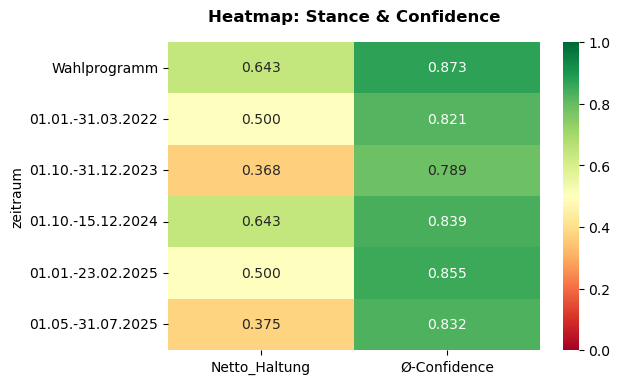

In [41]:

####### Auswertung für die CDU in der bürgergeld-Frage



client = OpenAI(api_key="sk-d-CKDAt5xmwp4kT5N7dMxA",base_url="https://hub.ki.fh-swf.de/v1")

# 1. Das präzise Schema für die Einzeltext-Klassifikation
class StanceAnalysis(BaseModel):
    stance: Literal["FAVOR", "AGAINST", "NEUTRAL", "IRRELEVANT"] = Field(
        description=(
            "The final overall stance toward the target topic. "
            "'FAVOR': Clearly supportive. "
            "'AGAINST': Clearly opposing. "
            "'NEUTRAL': Discusses the topic but takes a balanced, diplomatic, or non-judgmental stance. "
            "'IRRELEVANT': Does not mention or discuss the target topic at all."
        )
    )
    confidence_favor: float = Field(description="Confidence score for 'FAVOR' (0.0 to 1.0).")
    confidence_against: float = Field(description="Confidence score for 'AGAINST' (0.0 to 1.0).")
    confidence_neutral: float = Field(description="Confidence score for 'NEUTRAL' (0.0 to 1.0).")
    confidence_irrelevant: float = Field(description="Confidence score for 'IRRELEVANT' (0.0 to 1.0).")
    explanation: str = Field(description="A brief, one-sentence explanation of the stance classification.")

# 2. Zielthema als klare These definieren
target_topic = "Wir wollen das Bürgergeld abschaffen."

# --- SCHRITT A: DataFrame "aufbrechen" (Explode) ---
# Wir erstellen eine Kopie, damit Ihr Original-DataFrame unverändert bleibt
df_exploded = grouped_documents_bürgergeld_cdu.copy()

# Jedes einzelne Segment in der Liste bekommt nun eine eigene Zeile im DataFrame
df_exploded = df_exploded.explode('document').reset_index(drop=True)

# Listen zum Speichern der Ergebnisse initialisieren
stances = []
confidences = []
explanations = []

# 3. Schleife über alle EINZELNEN Segmente
print(f"Starte Analyse von insgesamt {len(df_exploded)} Textsegmenten...")

for index, row in df_exploded.iterrows():
    text_to_analyze = row['document']
    
    # Überspringe leere Segmente, falls vorhanden
    if pd.isna(text_to_analyze) or str(text_to_analyze).strip() == "":
        stances.append("IRRELEVANT")
        confidences.append(1.0)
        explanations.append("Empty text segment.")
        continue

    prompt = f"""Analyze the stance of the following short text segment toward the target topic.
Target Topic: {target_topic}
Text: {text_to_analyze}"""

    # API-Aufruf für jedes einzelne Segment mit strukturiertem Output (Structured Outputs)
    try:
        response = client.beta.chat.completions.parse(
            model="gpt-5-nano",
            messages=[
                {"role": "system", "content": "Du bist ein präzises, politikwissenschaftliches KI-System zur quantitativen Inhaltsanalyse. Deine Aufgabe ist es, Wahlprogramme und Bundestagsreden bezüglich ihrer Haltung zu analysieren.\
                                    Gibt das Ergebnis AUSSCHLIESSLICH als valides JSON-Objekt aus.\
                                    WICHTIG: achte auf Ironie, Sarkasmus und vage Aussagen"},
                {"role": "user", "content": prompt}
            ],
            response_format=StanceAnalysis,
            reasoning_effort="medium",
            seed=42
        )        
        
        # Extraktion der strukturierten Antwort
        result = response.choices[0].message.parsed
        
        # Werte in die Listen speichern
        stances.append(result.stance)

        # Speichert die Konfidenz basierend auf der gewählten Klasse
        if result.stance == "FAVOR":
            confidences.append(result.confidence_favor)
        elif result.stance == "AGAINST":
            confidences.append(result.confidence_against)
        elif result.stance == "NEUTRAL":
            confidences.append(result.confidence_neutral)
        elif result.stance == "IRRELEVANT":
            confidences.append(result.confidence_irrelevant)
        else:
            # Sicherheitsnetz für unvorhergesehene Fälle
            confidences.append(0.0)
    
        explanations.append(result.explanation)
        
    except Exception as e:
        print(f"Fehler bei Index {index}: {e}")
        stances.append("IRRELEVANT")
        confidences.append(0.0)
        explanations.append(f"API Error: {str(e)}")

# 4. Ergebnisse an das "aufgebrochene" DataFrame anhängen
df_exploded['stance'] = stances
df_exploded['confidence'] = confidences
df_exploded['explanation'] = explanations

print("Analyse abgeschlossen!")

# --- SCHRITT C: Aggregation (Optional) ---
# Falls Sie die Ergebnisse wieder auf die ursprüngliche Zeilenebene (pro Zeitraum/Partei) bringen möchten:

CONFIDENCE_THRESHOLD = 0.60

# 2. Flag auf Segment-Ebene setzen (True/1 wenn unsicher, False/0 wenn sicher)
df_exploded['is_low_confidence'] = df_exploded['confidence'] < CONFIDENCE_THRESHOLD

# 3. Aggregation durchführen
df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(
    Anzahl_Segmente=('document', 'count'),
    Anzahl_positiv=('stance', lambda x: (x == 'FAVOR').sum()),
    Anzahl_negativ=('stance', lambda x: (x == 'AGAINST').sum()),
    Anzahl_neutral_echt=('stance', lambda x: (x == 'NEUTRAL').sum()),
    Anzahl_irrelevant=('stance', lambda x: (x == 'IRRELEVANT').sum()),
    Durchschnitts_Confidence=('confidence', 'mean'),
    # HIER NEU: Zählt alle Segmente, bei denen die Confidence unter dem Schwellenwert lag
    Anzahl_Low_Confidence=('is_low_confidence', 'sum')
).reset_index()

# 4. Optional, aber dringend empfohlen für die Masterarbeit: Prozentualen Anteil berechnen
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = (df_aggregated_ukraine['Anzahl_Low_Confidence'] / df_aggregated_ukraine['Anzahl_Segmente']) * 100

# Kosmetische Rundung für eine saubere Tabelle
df_aggregated_ukraine['Durchschnitts_Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# 1. Netto-Haltungs-Score berechnen (0 bis +1.0)
# -> 1. Schritt: Summe der relevanten Segmente berechnen (ohne das Rauschen von IRRELEVANT)
df_aggregated_ukraine['Anzahl_relevant'] = (
    df_aggregated_ukraine['Anzahl_positiv'] + 
    df_aggregated_ukraine['Anzahl_negativ'] + 
    df_aggregated_ukraine['Anzahl_neutral_echt']
)

# -> 2. Schritt: Netto-Haltung berechnen
df_aggregated_ukraine['Netto_Haltung'] = (
    (df_aggregated_ukraine['Anzahl_positiv'] * 1.0) + 
    (df_aggregated_ukraine['Anzahl_neutral_echt'] * 0.5) +
    (df_aggregated_ukraine['Anzahl_negativ'] * 0.0)
) / df_aggregated_ukraine['Anzahl_relevant']

# 2. Anteil des Zeitraums an den Gesamtsegmenten der jeweiligen Partei (in %)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine.groupby('partei')['Anzahl_Segmente'].transform(lambda x: (x / x.sum()) * 100)

# 3. Kosmetische Rundung für die Tabelle in der Masterarbeit
df_aggregated_ukraine['Netto_Haltung'] = df_aggregated_ukraine['Netto_Haltung'].round(3)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine['Anteil an Gesamt in %'].round(1)

# Hier weisen wir die Rundung direkt der Spalte zu, die wir später in der Liste nutzen
df_aggregated_ukraine['Ø-Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence in %'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# KORREKTUR: Spaltennamen exakt an die Aggregations-Ergebnisse angepasst
spalten_ordnung = [
    'partei', 'zeitraum', 'Anzahl_Segmente', 'Anteil an Gesamt in %',
    'Anzahl_positiv', 'Anzahl_negativ', 'Anzahl_neutral_echt', 'Anzahl_irrelevant', 
    'Netto_Haltung', 'Ø-Confidence', 
    'Anzahl_Low_Confidence', 'Anteil_Low_Confidence in %'
]
df_aggregated_ukraine_final = df_aggregated_ukraine[spalten_ordnung]

# CSV-Export
df_aggregated_ukraine_final.to_csv('ergebnisse_bürgergeld_cdu.csv', sep=';', index=False, encoding='utf-8-sig')

# in LaTex überführen

latex_code = df_aggregated_ukraine_final.to_latex(index=False, caption='Analyse der Bürgergeld-Stance (CDU)', label='tab:meine_tabelle')
with open('ergebnisse_bürgergeld_cdu.tex', 'w') as f:
    f.write(latex_code)

# Schnelles Beispiel für die Heatmap-Struktur
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 1. Daten für die Heatmap vorbereiten
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 2. Eine neue Matplotlib-Figur erstellen, um die Größe und den Hintergrund zu definieren
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 3. Heatmap zeichnen (ax=ax stellt sicher, dass sie in unserer Figur landet)
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5, fmt=".3f", ax=ax)

# 4. Optische Feinschliffe (Titel hinzufügen und Achsen-Labels lesbar machen)
plt.title('Heatmap: Stance & Confidence', fontweight='bold', pad=15)
plt.yticks(rotation=0) # Sorgt dafür, dass die Datumsangaben links gerade stehen

# 5. Als scharfes JPG abspeichern
# 'bbox_inches="tight"' verhindert, dass die Datumsbeschriftungen am Rand abgeschnitten werden
plt.savefig('ergebnisse_bürgergeld_cdu_heatmap.jpg', dpi=200, bbox_inches='tight')

# 6. Plot im Notebook/Skript schließen, um Speicher zu sparen
plt.show()

Starte Analyse von insgesamt 289 Textsegmenten...
Analyse abgeschlossen!


/tmp/ipykernel_2702/1743097871.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(


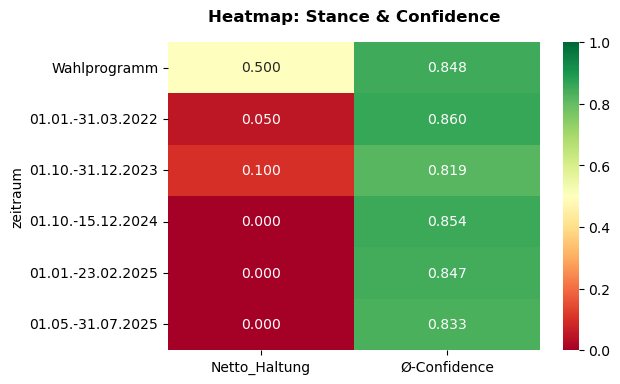

In [40]:

####### Auswertung für die SPD in der bürgergeld-Frage




client = OpenAI(api_key="sk-d-CKDAt5xmwp4kT5N7dMxA",base_url="https://hub.ki.fh-swf.de/v1")

# 1. Das präzise Schema für die Einzeltext-Klassifikation
class StanceAnalysis(BaseModel):
    stance: Literal["FAVOR", "AGAINST", "NEUTRAL", "IRRELEVANT"] = Field(
        description=(
            "The final overall stance toward the target topic. "
            "'FAVOR': Clearly supportive. "
            "'AGAINST': Clearly opposing. "
            "'NEUTRAL': Discusses the topic but takes a balanced, diplomatic, or non-judgmental stance. "
            "'IRRELEVANT': Does not mention or discuss the target topic at all."
        )
    )
    confidence_favor: float = Field(description="Confidence score for 'FAVOR' (0.0 to 1.0).")
    confidence_against: float = Field(description="Confidence score for 'AGAINST' (0.0 to 1.0).")
    confidence_neutral: float = Field(description="Confidence score for 'NEUTRAL' (0.0 to 1.0).")
    confidence_irrelevant: float = Field(description="Confidence score for 'IRRELEVANT' (0.0 to 1.0).")
    explanation: str = Field(description="A brief, one-sentence explanation of the stance classification.")

# 2. Zielthema als klare These definieren
target_topic = "Wir wollen das Bürgergeld abschaffen."

# --- SCHRITT A: DataFrame "aufbrechen" (Explode) ---
# Wir erstellen eine Kopie, damit Ihr Original-DataFrame unverändert bleibt
df_exploded = grouped_documents_bürgergeld_spd.copy()

# Jedes einzelne Segment in der Liste bekommt nun eine eigene Zeile im DataFrame
df_exploded = df_exploded.explode('document').reset_index(drop=True)

# Listen zum Speichern der Ergebnisse initialisieren
stances = []
confidences = []
explanations = []

# 3. Schleife über alle EINZELNEN Segmente
print(f"Starte Analyse von insgesamt {len(df_exploded)} Textsegmenten...")

for index, row in df_exploded.iterrows():
    text_to_analyze = row['document']
    
    # Überspringe leere Segmente, falls vorhanden
    if pd.isna(text_to_analyze) or str(text_to_analyze).strip() == "":
        stances.append("IRRELEVANT")
        confidences.append(1.0)
        explanations.append("Empty text segment.")
        continue

    prompt = f"""Analyze the stance of the following short text segment toward the target topic.
Target Topic: {target_topic}
Text: {text_to_analyze}"""

    # API-Aufruf für jedes einzelne Segment mit strukturiertem Output (Structured Outputs)
    try:
        response = client.beta.chat.completions.parse(
            model="gpt-5-nano",
            messages=[
                {"role": "system", "content": "Du bist ein präzises, politikwissenschaftliches KI-System zur quantitativen Inhaltsanalyse. Deine Aufgabe ist es, Wahlprogramme und Bundestagsreden bezüglich ihrer Haltung zu analysieren.\
                                    Gibt das Ergebnis AUSSCHLIESSLICH als valides JSON-Objekt aus.\
                                    WICHTIG: achte auf Ironie, Sarkasmus und vage Aussagen"},
                {"role": "user", "content": prompt}
            ],
            response_format=StanceAnalysis,
            reasoning_effort="medium",
            seed=42
        )        
        
        # Extraktion der strukturierten Antwort
        result = response.choices[0].message.parsed
        
        # Werte in die Listen speichern
        stances.append(result.stance)

        # Speichert die Konfidenz basierend auf der gewählten Klasse
        if result.stance == "FAVOR":
            confidences.append(result.confidence_favor)
        elif result.stance == "AGAINST":
            confidences.append(result.confidence_against)
        elif result.stance == "NEUTRAL":
            confidences.append(result.confidence_neutral)
        elif result.stance == "IRRELEVANT":
            confidences.append(result.confidence_irrelevant)
        else:
            # Sicherheitsnetz für unvorhergesehene Fälle
            confidences.append(0.0)
    
        explanations.append(result.explanation)
        
    except Exception as e:
        print(f"Fehler bei Index {index}: {e}")
        stances.append("IRRELEVANT")
        confidences.append(0.0)
        explanations.append(f"API Error: {str(e)}")

# 4. Ergebnisse an das "aufgebrochene" DataFrame anhängen
df_exploded['stance'] = stances
df_exploded['confidence'] = confidences
df_exploded['explanation'] = explanations

print("Analyse abgeschlossen!")

# --- SCHRITT C: Aggregation (Optional) ---
# Falls Sie die Ergebnisse wieder auf die ursprüngliche Zeilenebene (pro Zeitraum/Partei) bringen möchten:

CONFIDENCE_THRESHOLD = 0.60

# 2. Flag auf Segment-Ebene setzen (True/1 wenn unsicher, False/0 wenn sicher)
df_exploded['is_low_confidence'] = df_exploded['confidence'] < CONFIDENCE_THRESHOLD

# 3. Aggregation durchführen
df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(
    Anzahl_Segmente=('document', 'count'),
    Anzahl_positiv=('stance', lambda x: (x == 'FAVOR').sum()),
    Anzahl_negativ=('stance', lambda x: (x == 'AGAINST').sum()),
    Anzahl_neutral_echt=('stance', lambda x: (x == 'NEUTRAL').sum()),
    Anzahl_irrelevant=('stance', lambda x: (x == 'IRRELEVANT').sum()),
    Durchschnitts_Confidence=('confidence', 'mean'),
    # HIER NEU: Zählt alle Segmente, bei denen die Confidence unter dem Schwellenwert lag
    Anzahl_Low_Confidence=('is_low_confidence', 'sum')
).reset_index()

# 4. Optional, aber dringend empfohlen für die Masterarbeit: Prozentualen Anteil berechnen
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = (df_aggregated_ukraine['Anzahl_Low_Confidence'] / df_aggregated_ukraine['Anzahl_Segmente']) * 100

# Kosmetische Rundung für eine saubere Tabelle
df_aggregated_ukraine['Durchschnitts_Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# 1. Netto-Haltungs-Score berechnen (0 bis +1.0)
# -> 1. Schritt: Summe der relevanten Segmente berechnen (ohne das Rauschen von IRRELEVANT)
df_aggregated_ukraine['Anzahl_relevant'] = (
    df_aggregated_ukraine['Anzahl_positiv'] + 
    df_aggregated_ukraine['Anzahl_negativ'] + 
    df_aggregated_ukraine['Anzahl_neutral_echt']
)

# -> 2. Schritt: Netto-Haltung berechnen
df_aggregated_ukraine['Netto_Haltung'] = (
    (df_aggregated_ukraine['Anzahl_positiv'] * 1.0) + 
    (df_aggregated_ukraine['Anzahl_neutral_echt'] * 0.5) +
    (df_aggregated_ukraine['Anzahl_negativ'] * 0.0)
) / df_aggregated_ukraine['Anzahl_relevant']

# 2. Anteil des Zeitraums an den Gesamtsegmenten der jeweiligen Partei (in %)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine.groupby('partei')['Anzahl_Segmente'].transform(lambda x: (x / x.sum()) * 100)

# 3. Kosmetische Rundung für die Tabelle in der Masterarbeit
df_aggregated_ukraine['Netto_Haltung'] = df_aggregated_ukraine['Netto_Haltung'].round(3)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine['Anteil an Gesamt in %'].round(1)

# Hier weisen wir die Rundung direkt der Spalte zu, die wir später in der Liste nutzen
df_aggregated_ukraine['Ø-Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence in %'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# KORREKTUR: Spaltennamen exakt an die Aggregations-Ergebnisse angepasst
spalten_ordnung = [
    'partei', 'zeitraum', 'Anzahl_Segmente', 'Anteil an Gesamt in %',
    'Anzahl_positiv', 'Anzahl_negativ', 'Anzahl_neutral_echt', 'Anzahl_irrelevant', 
    'Netto_Haltung', 'Ø-Confidence', 
    'Anzahl_Low_Confidence', 'Anteil_Low_Confidence in %'
]
df_aggregated_ukraine_final = df_aggregated_ukraine[spalten_ordnung]

# CSV-Export
df_aggregated_ukraine_final.to_csv('ergebnisse_bürgergeld_spd.csv', sep=';', index=False, encoding='utf-8-sig')

# in LaTex überführen

latex_code = df_aggregated_ukraine_final.to_latex(index=False, caption='Analyse der Bürgergeld-Stance (SPD)', label='tab:meine_tabelle')
with open('ergebnisse_bürgergeld_spd.tex', 'w') as f:
    f.write(latex_code)

# Schnelles Beispiel für die Heatmap-Struktur
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 1. Daten für die Heatmap vorbereiten
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 2. Eine neue Matplotlib-Figur erstellen, um die Größe und den Hintergrund zu definieren
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 3. Heatmap zeichnen (ax=ax stellt sicher, dass sie in unserer Figur landet)
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5, fmt=".3f", ax=ax)

# 4. Optische Feinschliffe (Titel hinzufügen und Achsen-Labels lesbar machen)
plt.title('Heatmap: Stance & Confidence', fontweight='bold', pad=15)
plt.yticks(rotation=0) # Sorgt dafür, dass die Datumsangaben links gerade stehen

# 5. Als scharfes JPG abspeichern
# 'bbox_inches="tight"' verhindert, dass die Datumsbeschriftungen am Rand abgeschnitten werden
plt.savefig('ergebnisse_bürgergeld_spd_heatmap.jpg', dpi=200, bbox_inches='tight')

# 6. Plot im Notebook/Skript schließen, um Speicher zu sparen
plt.show()

Starte Analyse von insgesamt 159 Textsegmenten...
Analyse abgeschlossen!


/tmp/ipykernel_2702/1748076371.py:117: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(


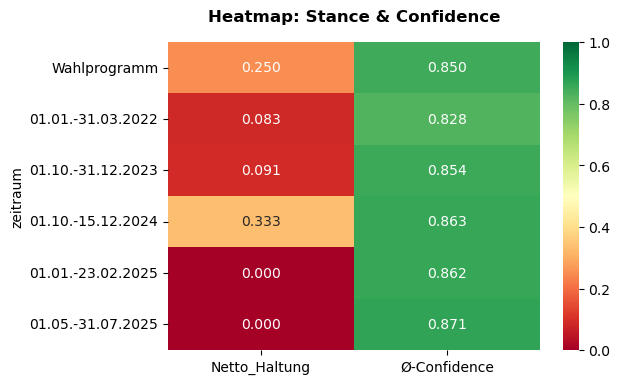

In [39]:

####### Auswertung für die Grüne in der bürgergeld-Frage





client = OpenAI(api_key="sk-d-CKDAt5xmwp4kT5N7dMxA",base_url="https://hub.ki.fh-swf.de/v1")

# 1. Das präzise Schema für die Einzeltext-Klassifikation
class StanceAnalysis(BaseModel):
    stance: Literal["FAVOR", "AGAINST", "NEUTRAL", "IRRELEVANT"] = Field(
        description=(
            "The final overall stance toward the target topic. "
            "'FAVOR': Clearly supportive. "
            "'AGAINST': Clearly opposing. "
            "'NEUTRAL': Discusses the topic but takes a balanced, diplomatic, or non-judgmental stance. "
            "'IRRELEVANT': Does not mention or discuss the target topic at all."
        )
    )
    confidence_favor: float = Field(description="Confidence score for 'FAVOR' (0.0 to 1.0).")
    confidence_against: float = Field(description="Confidence score for 'AGAINST' (0.0 to 1.0).")
    confidence_neutral: float = Field(description="Confidence score for 'NEUTRAL' (0.0 to 1.0).")
    confidence_irrelevant: float = Field(description="Confidence score for 'IRRELEVANT' (0.0 to 1.0).")
    explanation: str = Field(description="A brief, one-sentence explanation of the stance classification.")

# 2. Zielthema als klare These definieren
target_topic = "Wir wollen das Bürgergeld abschaffen."

# --- SCHRITT A: DataFrame "aufbrechen" (Explode) ---
# Wir erstellen eine Kopie, damit Ihr Original-DataFrame unverändert bleibt
# df_exploded = grouped_documents_ukraine_fdp.copy()
df_exploded = grouped_documents_bürgergeld_grüne.copy()

# Jedes einzelne Segment in der Liste bekommt nun eine eigene Zeile im DataFrame
df_exploded = df_exploded.explode('document').reset_index(drop=True)

# Listen zum Speichern der Ergebnisse initialisieren
stances = []
confidences = []
explanations = []

# 3. Schleife über alle EINZELNEN Segmente
print(f"Starte Analyse von insgesamt {len(df_exploded)} Textsegmenten...")

for index, row in df_exploded.iterrows():
    text_to_analyze = row['document']
    
    # Überspringe leere Segmente, falls vorhanden
    if pd.isna(text_to_analyze) or str(text_to_analyze).strip() == "":
        stances.append("IRRELEVANT")
        confidences.append(1.0)
        explanations.append("Empty text segment.")
        continue

    prompt = f"""Analyze the stance of the following short text segment toward the target topic.
Target Topic: {target_topic}
Text: {text_to_analyze}"""

    # API-Aufruf für jedes einzelne Segment mit strukturiertem Output (Structured Outputs)
    try:
        response = client.beta.chat.completions.parse(
            model="gpt-5-nano",
            messages=[
                {"role": "system", "content": "Du bist ein präzises, politikwissenschaftliches KI-System zur quantitativen Inhaltsanalyse. Deine Aufgabe ist es, Wahlprogramme und Bundestagsreden bezüglich ihrer Haltung zu analysieren.\
                                    Gibt das Ergebnis AUSSCHLIESSLICH als valides JSON-Objekt aus.\
                                    WICHTIG: achte auf Ironie, Sarkasmus und vage Aussagen"},
                {"role": "user", "content": prompt}
            ],
            response_format=StanceAnalysis,
            reasoning_effort="medium",
            seed=42
        )        
        
        # Extraktion der strukturierten Antwort
        result = response.choices[0].message.parsed
        
        # Werte in die Listen speichern
        stances.append(result.stance)

        # Speichert die Konfidenz basierend auf der gewählten Klasse
        if result.stance == "FAVOR":
            confidences.append(result.confidence_favor)
        elif result.stance == "AGAINST":
            confidences.append(result.confidence_against)
        elif result.stance == "NEUTRAL":
            confidences.append(result.confidence_neutral)
        elif result.stance == "IRRELEVANT":
            confidences.append(result.confidence_irrelevant)
        else:
            # Sicherheitsnetz für unvorhergesehene Fälle
            confidences.append(0.0)
    
        explanations.append(result.explanation)
        
    except Exception as e:
        print(f"Fehler bei Index {index}: {e}")
        stances.append("IRRELEVANT")
        confidences.append(0.0)
        explanations.append(f"API Error: {str(e)}")

# 4. Ergebnisse an das "aufgebrochene" DataFrame anhängen
df_exploded['stance'] = stances
df_exploded['confidence'] = confidences
df_exploded['explanation'] = explanations

print("Analyse abgeschlossen!")

# --- SCHRITT C: Aggregation (Optional) ---
# Falls Sie die Ergebnisse wieder auf die ursprüngliche Zeilenebene (pro Zeitraum/Partei) bringen möchten:

CONFIDENCE_THRESHOLD = 0.60

# 2. Flag auf Segment-Ebene setzen (True/1 wenn unsicher, False/0 wenn sicher)
df_exploded['is_low_confidence'] = df_exploded['confidence'] < CONFIDENCE_THRESHOLD

# 3. Aggregation durchführen
df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(
    Anzahl_Segmente=('document', 'count'),
    Anzahl_positiv=('stance', lambda x: (x == 'FAVOR').sum()),
    Anzahl_negativ=('stance', lambda x: (x == 'AGAINST').sum()),
    Anzahl_neutral_echt=('stance', lambda x: (x == 'NEUTRAL').sum()),
    Anzahl_irrelevant=('stance', lambda x: (x == 'IRRELEVANT').sum()),
    Durchschnitts_Confidence=('confidence', 'mean'),
    # HIER NEU: Zählt alle Segmente, bei denen die Confidence unter dem Schwellenwert lag
    Anzahl_Low_Confidence=('is_low_confidence', 'sum')
).reset_index()

# 4. Optional, aber dringend empfohlen für die Masterarbeit: Prozentualen Anteil berechnen
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = (df_aggregated_ukraine['Anzahl_Low_Confidence'] / df_aggregated_ukraine['Anzahl_Segmente']) * 100

# Kosmetische Rundung für eine saubere Tabelle
df_aggregated_ukraine['Durchschnitts_Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# 1. Netto-Haltungs-Score berechnen (0 bis +1.0)
# -> 1. Schritt: Summe der relevanten Segmente berechnen (ohne das Rauschen von IRRELEVANT)
df_aggregated_ukraine['Anzahl_relevant'] = (
    df_aggregated_ukraine['Anzahl_positiv'] + 
    df_aggregated_ukraine['Anzahl_negativ'] + 
    df_aggregated_ukraine['Anzahl_neutral_echt']
)

# -> 2. Schritt: Netto-Haltung berechnen
df_aggregated_ukraine['Netto_Haltung'] = (
    (df_aggregated_ukraine['Anzahl_positiv'] * 1.0) + 
    (df_aggregated_ukraine['Anzahl_neutral_echt'] * 0.5) +
    (df_aggregated_ukraine['Anzahl_negativ'] * 0.0)
) / df_aggregated_ukraine['Anzahl_relevant']

# 2. Anteil des Zeitraums an den Gesamtsegmenten der jeweiligen Partei (in %)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine.groupby('partei')['Anzahl_Segmente'].transform(lambda x: (x / x.sum()) * 100)

# 3. Kosmetische Rundung für die Tabelle in der Masterarbeit
df_aggregated_ukraine['Netto_Haltung'] = df_aggregated_ukraine['Netto_Haltung'].round(3)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine['Anteil an Gesamt in %'].round(1)

# Hier weisen wir die Rundung direkt der Spalte zu, die wir später in der Liste nutzen
df_aggregated_ukraine['Ø-Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence in %'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# KORREKTUR: Spaltennamen exakt an die Aggregations-Ergebnisse angepasst
spalten_ordnung = [
    'partei', 'zeitraum', 'Anzahl_Segmente', 'Anteil an Gesamt in %',
    'Anzahl_positiv', 'Anzahl_negativ', 'Anzahl_neutral_echt', 'Anzahl_irrelevant', 
    'Netto_Haltung', 'Ø-Confidence', 
    'Anzahl_Low_Confidence', 'Anteil_Low_Confidence in %'
]
df_aggregated_ukraine_final = df_aggregated_ukraine[spalten_ordnung]

# CSV-Export
df_aggregated_ukraine_final.to_csv('ergebnisse_bürgergeld_grüne.csv', sep=';', index=False, encoding='utf-8-sig')

# in LaTex überführen

latex_code = df_aggregated_ukraine_final.to_latex(index=False, caption='Analyse der Bürgergeld-Stance (Grüne)', label='tab:meine_tabelle')
with open('ergebnisse_bürgergeld_grüne.tex', 'w') as f:
    f.write(latex_code)

# Schnelles Beispiel für die Heatmap-Struktur
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 1. Daten für die Heatmap vorbereiten
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 2. Eine neue Matplotlib-Figur erstellen, um die Größe und den Hintergrund zu definieren
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 3. Heatmap zeichnen (ax=ax stellt sicher, dass sie in unserer Figur landet)
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5, fmt=".3f", ax=ax)

# 4. Optische Feinschliffe (Titel hinzufügen und Achsen-Labels lesbar machen)
plt.title('Heatmap: Stance & Confidence', fontweight='bold', pad=15)
plt.yticks(rotation=0) # Sorgt dafür, dass die Datumsangaben links gerade stehen

# 5. Als scharfes JPG abspeichern
# 'bbox_inches="tight"' verhindert, dass die Datumsbeschriftungen am Rand abgeschnitten werden
plt.savefig('ergebnisse_bürgergeld_grüne_heatmap.jpg', dpi=200, bbox_inches='tight')

# 6. Plot im Notebook/Skript schließen, um Speicher zu sparen
plt.show()

Starte Analyse von insgesamt 163 Textsegmenten...
Analyse abgeschlossen!


/tmp/ipykernel_2702/3146986352.py:117: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(


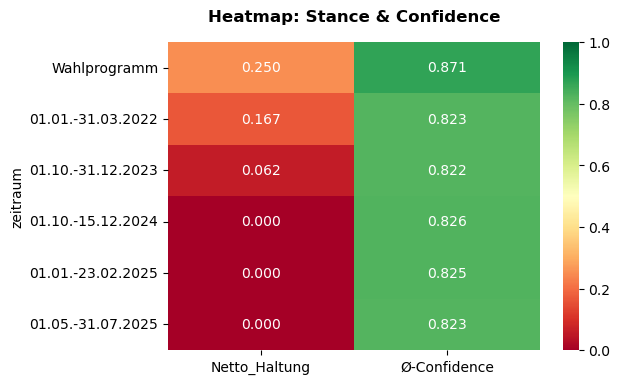

In [38]:

####### Auswertung für die Linke in der bürgergeld-Frage





client = OpenAI(api_key="sk-d-CKDAt5xmwp4kT5N7dMxA",base_url="https://hub.ki.fh-swf.de/v1")

# 1. Das präzise Schema für die Einzeltext-Klassifikation
class StanceAnalysis(BaseModel):
    stance: Literal["FAVOR", "AGAINST", "NEUTRAL", "IRRELEVANT"] = Field(
        description=(
            "The final overall stance toward the target topic. "
            "'FAVOR': Clearly supportive. "
            "'AGAINST': Clearly opposing. "
            "'NEUTRAL': Discusses the topic but takes a balanced, diplomatic, or non-judgmental stance. "
            "'IRRELEVANT': Does not mention or discuss the target topic at all."
        )
    )
    confidence_favor: float = Field(description="Confidence score for 'FAVOR' (0.0 to 1.0).")
    confidence_against: float = Field(description="Confidence score for 'AGAINST' (0.0 to 1.0).")
    confidence_neutral: float = Field(description="Confidence score for 'NEUTRAL' (0.0 to 1.0).")
    confidence_irrelevant: float = Field(description="Confidence score for 'IRRELEVANT' (0.0 to 1.0).")
    explanation: str = Field(description="A brief, one-sentence explanation of the stance classification.")

# 2. Zielthema als klare These definieren
target_topic = "Wir wollen das Bürgergeld abschaffen."

# --- SCHRITT A: DataFrame "aufbrechen" (Explode) ---
# Wir erstellen eine Kopie, damit Ihr Original-DataFrame unverändert bleibt
# df_exploded = grouped_documents_ukraine_fdp.copy()
df_exploded = grouped_documents_bürgergeld_linke.copy()

# Jedes einzelne Segment in der Liste bekommt nun eine eigene Zeile im DataFrame
df_exploded = df_exploded.explode('document').reset_index(drop=True)

# Listen zum Speichern der Ergebnisse initialisieren
stances = []
confidences = []
explanations = []

# 3. Schleife über alle EINZELNEN Segmente
print(f"Starte Analyse von insgesamt {len(df_exploded)} Textsegmenten...")

for index, row in df_exploded.iterrows():
    text_to_analyze = row['document']
    
    # Überspringe leere Segmente, falls vorhanden
    if pd.isna(text_to_analyze) or str(text_to_analyze).strip() == "":
        stances.append("IRRELEVANT")
        confidences.append(1.0)
        explanations.append("Empty text segment.")
        continue

    prompt = f"""Analyze the stance of the following short text segment toward the target topic.
Target Topic: {target_topic}
Text: {text_to_analyze}"""

    # API-Aufruf für jedes einzelne Segment mit strukturiertem Output (Structured Outputs)
    try:
        response = client.beta.chat.completions.parse(
            model="gpt-5-nano",
            messages=[
                {"role": "system", "content": "Du bist ein präzises, politikwissenschaftliches KI-System zur quantitativen Inhaltsanalyse. Deine Aufgabe ist es, Wahlprogramme und Bundestagsreden bezüglich ihrer Haltung zu analysieren.\
                                    Gibt das Ergebnis AUSSCHLIESSLICH als valides JSON-Objekt aus.\
                                    WICHTIG: achte auf Ironie, Sarkasmus und vage Aussagen"},
                {"role": "user", "content": prompt}
            ],
            response_format=StanceAnalysis,
            reasoning_effort="medium",
            seed=42
        )        
        
        # Extraktion der strukturierten Antwort
        result = response.choices[0].message.parsed
        
        # Werte in die Listen speichern
        stances.append(result.stance)

        # Speichert die Konfidenz basierend auf der gewählten Klasse
        if result.stance == "FAVOR":
            confidences.append(result.confidence_favor)
        elif result.stance == "AGAINST":
            confidences.append(result.confidence_against)
        elif result.stance == "NEUTRAL":
            confidences.append(result.confidence_neutral)
        elif result.stance == "IRRELEVANT":
            confidences.append(result.confidence_irrelevant)
        else:
            # Sicherheitsnetz für unvorhergesehene Fälle
            confidences.append(0.0)
    
        explanations.append(result.explanation)
        
    except Exception as e:
        print(f"Fehler bei Index {index}: {e}")
        stances.append("IRRELEVANT")
        confidences.append(0.0)
        explanations.append(f"API Error: {str(e)}")

# 4. Ergebnisse an das "aufgebrochene" DataFrame anhängen
df_exploded['stance'] = stances
df_exploded['confidence'] = confidences
df_exploded['explanation'] = explanations

print("Analyse abgeschlossen!")

# --- SCHRITT C: Aggregation (Optional) ---
# Falls Sie die Ergebnisse wieder auf die ursprüngliche Zeilenebene (pro Zeitraum/Partei) bringen möchten:

CONFIDENCE_THRESHOLD = 0.60

# 2. Flag auf Segment-Ebene setzen (True/1 wenn unsicher, False/0 wenn sicher)
df_exploded['is_low_confidence'] = df_exploded['confidence'] < CONFIDENCE_THRESHOLD

# 3. Aggregation durchführen
df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(
    Anzahl_Segmente=('document', 'count'),
    Anzahl_positiv=('stance', lambda x: (x == 'FAVOR').sum()),
    Anzahl_negativ=('stance', lambda x: (x == 'AGAINST').sum()),
    Anzahl_neutral_echt=('stance', lambda x: (x == 'NEUTRAL').sum()),
    Anzahl_irrelevant=('stance', lambda x: (x == 'IRRELEVANT').sum()),
    Durchschnitts_Confidence=('confidence', 'mean'),
    # HIER NEU: Zählt alle Segmente, bei denen die Confidence unter dem Schwellenwert lag
    Anzahl_Low_Confidence=('is_low_confidence', 'sum')
).reset_index()

# 4. Optional, aber dringend empfohlen für die Masterarbeit: Prozentualen Anteil berechnen
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = (df_aggregated_ukraine['Anzahl_Low_Confidence'] / df_aggregated_ukraine['Anzahl_Segmente']) * 100

# Kosmetische Rundung für eine saubere Tabelle
df_aggregated_ukraine['Durchschnitts_Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# 1. Netto-Haltungs-Score berechnen (0 bis +1.0)
# -> 1. Schritt: Summe der relevanten Segmente berechnen (ohne das Rauschen von IRRELEVANT)
df_aggregated_ukraine['Anzahl_relevant'] = (
    df_aggregated_ukraine['Anzahl_positiv'] + 
    df_aggregated_ukraine['Anzahl_negativ'] + 
    df_aggregated_ukraine['Anzahl_neutral_echt']
)

# -> 2. Schritt: Netto-Haltung berechnen
df_aggregated_ukraine['Netto_Haltung'] = (
    (df_aggregated_ukraine['Anzahl_positiv'] * 1.0) + 
    (df_aggregated_ukraine['Anzahl_neutral_echt'] * 0.5) +
    (df_aggregated_ukraine['Anzahl_negativ'] * 0.0)
) / df_aggregated_ukraine['Anzahl_relevant']

# 2. Anteil des Zeitraums an den Gesamtsegmenten der jeweiligen Partei (in %)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine.groupby('partei')['Anzahl_Segmente'].transform(lambda x: (x / x.sum()) * 100)

# 3. Kosmetische Rundung für die Tabelle in der Masterarbeit
df_aggregated_ukraine['Netto_Haltung'] = df_aggregated_ukraine['Netto_Haltung'].round(3)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine['Anteil an Gesamt in %'].round(1)

# Hier weisen wir die Rundung direkt der Spalte zu, die wir später in der Liste nutzen
df_aggregated_ukraine['Ø-Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence in %'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# KORREKTUR: Spaltennamen exakt an die Aggregations-Ergebnisse angepasst
spalten_ordnung = [
    'partei', 'zeitraum', 'Anzahl_Segmente', 'Anteil an Gesamt in %',
    'Anzahl_positiv', 'Anzahl_negativ', 'Anzahl_neutral_echt', 'Anzahl_irrelevant', 
    'Netto_Haltung', 'Ø-Confidence', 
    'Anzahl_Low_Confidence', 'Anteil_Low_Confidence in %'
]
df_aggregated_ukraine_final = df_aggregated_ukraine[spalten_ordnung]

# CSV-Export
df_aggregated_ukraine_final.to_csv('ergebnisse_bürgergeld_linke.csv', sep=';', index=False, encoding='utf-8-sig')

# in LaTex überführen

latex_code = df_aggregated_ukraine_final.to_latex(index=False, caption='Analyse der Bürgergelde-Stance (Linke)', label='tab:meine_tabelle')
with open('ergebnisse_bürgergeld_linke.tex', 'w') as f:
    f.write(latex_code)

# Schnelles Beispiel für die Heatmap-Struktur
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 1. Daten für die Heatmap vorbereiten
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 2. Eine neue Matplotlib-Figur erstellen, um die Größe und den Hintergrund zu definieren
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 3. Heatmap zeichnen (ax=ax stellt sicher, dass sie in unserer Figur landet)
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5, fmt=".3f", ax=ax)

# 4. Optische Feinschliffe (Titel hinzufügen und Achsen-Labels lesbar machen)
plt.title('Heatmap: Stance & Confidence', fontweight='bold', pad=15)
plt.yticks(rotation=0) # Sorgt dafür, dass die Datumsangaben links gerade stehen

# 5. Als scharfes JPG abspeichern
# 'bbox_inches="tight"' verhindert, dass die Datumsbeschriftungen am Rand abgeschnitten werden
plt.savefig('ergebnisse_bürgergeld_linke_heatmap.jpg', dpi=200, bbox_inches='tight')

# 6. Plot im Notebook/Skript schließen, um Speicher zu sparen
plt.show()

Starte Analyse von insgesamt 165 Textsegmenten...
Analyse abgeschlossen!


/tmp/ipykernel_2702/2650928853.py:117: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(


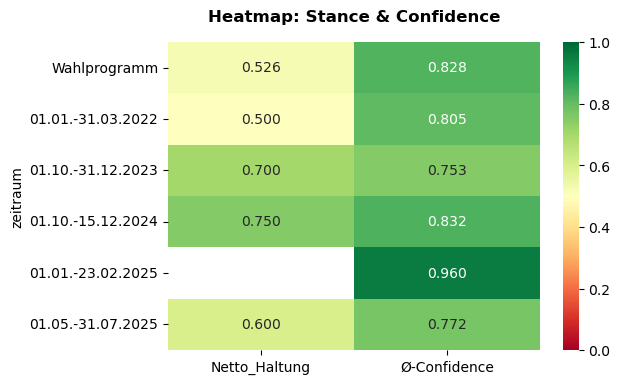

In [37]:

####### Auswertung für die AfD in der bürgergeld-Frage





client = OpenAI(api_key="sk-d-CKDAt5xmwp4kT5N7dMxA",base_url="https://hub.ki.fh-swf.de/v1")

# 1. Das präzise Schema für die Einzeltext-Klassifikation
class StanceAnalysis(BaseModel):
    stance: Literal["FAVOR", "AGAINST", "NEUTRAL", "IRRELEVANT"] = Field(
        description=(
            "The final overall stance toward the target topic. "
            "'FAVOR': Clearly supportive. "
            "'AGAINST': Clearly opposing. "
            "'NEUTRAL': Discusses the topic but takes a balanced, diplomatic, or non-judgmental stance. "
            "'IRRELEVANT': Does not mention or discuss the target topic at all."
        )
    )
    confidence_favor: float = Field(description="Confidence score for 'FAVOR' (0.0 to 1.0).")
    confidence_against: float = Field(description="Confidence score for 'AGAINST' (0.0 to 1.0).")
    confidence_neutral: float = Field(description="Confidence score for 'NEUTRAL' (0.0 to 1.0).")
    confidence_irrelevant: float = Field(description="Confidence score for 'IRRELEVANT' (0.0 to 1.0).")
    explanation: str = Field(description="A brief, one-sentence explanation of the stance classification.")

# 2. Zielthema als klare These definieren
target_topic = "Wir wollen das Bürgergeld abschaffen."

# --- SCHRITT A: DataFrame "aufbrechen" (Explode) ---
# Wir erstellen eine Kopie, damit Ihr Original-DataFrame unverändert bleibt
# df_exploded = grouped_documents_ukraine_fdp.copy()
df_exploded = grouped_documents_bürgergeld_afd.copy()

# Jedes einzelne Segment in der Liste bekommt nun eine eigene Zeile im DataFrame
df_exploded = df_exploded.explode('document').reset_index(drop=True)

# Listen zum Speichern der Ergebnisse initialisieren
stances = []
confidences = []
explanations = []

# 3. Schleife über alle EINZELNEN Segmente
print(f"Starte Analyse von insgesamt {len(df_exploded)} Textsegmenten...")

for index, row in df_exploded.iterrows():
    text_to_analyze = row['document']
    
    # Überspringe leere Segmente, falls vorhanden
    if pd.isna(text_to_analyze) or str(text_to_analyze).strip() == "":
        stances.append("IRRELEVANT")
        confidences.append(1.0)
        explanations.append("Empty text segment.")
        continue

    prompt = f"""Analyze the stance of the following short text segment toward the target topic.
Target Topic: {target_topic}
Text: {text_to_analyze}"""

    # API-Aufruf für jedes einzelne Segment mit strukturiertem Output (Structured Outputs)
    try:
        response = client.beta.chat.completions.parse(
            model="gpt-5-nano",
            messages=[
                {"role": "system", "content": "Du bist ein präzises, politikwissenschaftliches KI-System zur quantitativen Inhaltsanalyse. Deine Aufgabe ist es, Wahlprogramme und Bundestagsreden bezüglich ihrer Haltung zu analysieren.\
                                    Gibt das Ergebnis AUSSCHLIESSLICH als valides JSON-Objekt aus.\
                                    WICHTIG: achte auf Ironie, Sarkasmus und vage Aussagen"},
                {"role": "user", "content": prompt}
            ],
            response_format=StanceAnalysis,
            reasoning_effort="medium",
            seed=42
        )        
        
        # Extraktion der strukturierten Antwort
        result = response.choices[0].message.parsed
        
        # Werte in die Listen speichern
        stances.append(result.stance)

        # Speichert die Konfidenz basierend auf der gewählten Klasse
        if result.stance == "FAVOR":
            confidences.append(result.confidence_favor)
        elif result.stance == "AGAINST":
            confidences.append(result.confidence_against)
        elif result.stance == "NEUTRAL":
            confidences.append(result.confidence_neutral)
        elif result.stance == "IRRELEVANT":
            confidences.append(result.confidence_irrelevant)
        else:
            # Sicherheitsnetz für unvorhergesehene Fälle
            confidences.append(0.0)
    
        explanations.append(result.explanation)
        
    except Exception as e:
        print(f"Fehler bei Index {index}: {e}")
        stances.append("IRRELEVANT")
        confidences.append(0.0)
        explanations.append(f"API Error: {str(e)}")

# 4. Ergebnisse an das "aufgebrochene" DataFrame anhängen
df_exploded['stance'] = stances
df_exploded['confidence'] = confidences
df_exploded['explanation'] = explanations

print("Analyse abgeschlossen!")

# --- SCHRITT C: Aggregation (Optional) ---
# Falls Sie die Ergebnisse wieder auf die ursprüngliche Zeilenebene (pro Zeitraum/Partei) bringen möchten:

CONFIDENCE_THRESHOLD = 0.60

# 2. Flag auf Segment-Ebene setzen (True/1 wenn unsicher, False/0 wenn sicher)
df_exploded['is_low_confidence'] = df_exploded['confidence'] < CONFIDENCE_THRESHOLD

# 3. Aggregation durchführen
df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(
    Anzahl_Segmente=('document', 'count'),
    Anzahl_positiv=('stance', lambda x: (x == 'FAVOR').sum()),
    Anzahl_negativ=('stance', lambda x: (x == 'AGAINST').sum()),
    Anzahl_neutral_echt=('stance', lambda x: (x == 'NEUTRAL').sum()),
    Anzahl_irrelevant=('stance', lambda x: (x == 'IRRELEVANT').sum()),
    Durchschnitts_Confidence=('confidence', 'mean'),
    # HIER NEU: Zählt alle Segmente, bei denen die Confidence unter dem Schwellenwert lag
    Anzahl_Low_Confidence=('is_low_confidence', 'sum')
).reset_index()

# 4. Optional, aber dringend empfohlen für die Masterarbeit: Prozentualen Anteil berechnen
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = (df_aggregated_ukraine['Anzahl_Low_Confidence'] / df_aggregated_ukraine['Anzahl_Segmente']) * 100

# Kosmetische Rundung für eine saubere Tabelle
df_aggregated_ukraine['Durchschnitts_Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# 1. Netto-Haltungs-Score berechnen (0 bis +1.0)
# -> 1. Schritt: Summe der relevanten Segmente berechnen (ohne das Rauschen von IRRELEVANT)
df_aggregated_ukraine['Anzahl_relevant'] = (
    df_aggregated_ukraine['Anzahl_positiv'] + 
    df_aggregated_ukraine['Anzahl_negativ'] + 
    df_aggregated_ukraine['Anzahl_neutral_echt']
)

# -> 2. Schritt: Netto-Haltung berechnen
df_aggregated_ukraine['Netto_Haltung'] = (
    (df_aggregated_ukraine['Anzahl_positiv'] * 1.0) + 
    (df_aggregated_ukraine['Anzahl_neutral_echt'] * 0.5) +
    (df_aggregated_ukraine['Anzahl_negativ'] * 0.0)
) / df_aggregated_ukraine['Anzahl_relevant']

# 2. Anteil des Zeitraums an den Gesamtsegmenten der jeweiligen Partei (in %)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine.groupby('partei')['Anzahl_Segmente'].transform(lambda x: (x / x.sum()) * 100)

# 3. Kosmetische Rundung für die Tabelle in der Masterarbeit
df_aggregated_ukraine['Netto_Haltung'] = df_aggregated_ukraine['Netto_Haltung'].round(3)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine['Anteil an Gesamt in %'].round(1)

# Hier weisen wir die Rundung direkt der Spalte zu, die wir später in der Liste nutzen
df_aggregated_ukraine['Ø-Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence in %'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# KORREKTUR: Spaltennamen exakt an die Aggregations-Ergebnisse angepasst
spalten_ordnung = [
    'partei', 'zeitraum', 'Anzahl_Segmente', 'Anteil an Gesamt in %',
    'Anzahl_positiv', 'Anzahl_negativ', 'Anzahl_neutral_echt', 'Anzahl_irrelevant', 
    'Netto_Haltung', 'Ø-Confidence', 
    'Anzahl_Low_Confidence', 'Anteil_Low_Confidence in %'
]
df_aggregated_ukraine_final = df_aggregated_ukraine[spalten_ordnung]

# CSV-Export
df_aggregated_ukraine_final.to_csv('ergebnisse_bürgergeld_afd.csv', sep=';', index=False, encoding='utf-8-sig')

# in LaTex überführen

latex_code = df_aggregated_ukraine_final.to_latex(index=False, caption='Analyse der Bürgergeld-Stance (AfD)', label='tab:meine_tabelle')
with open('ergebnisse_bürgergeld_afd.tex', 'w') as f:
    f.write(latex_code)

# Schnelles Beispiel für die Heatmap-Struktur
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 1. Daten für die Heatmap vorbereiten
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 2. Eine neue Matplotlib-Figur erstellen, um die Größe und den Hintergrund zu definieren
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 3. Heatmap zeichnen (ax=ax stellt sicher, dass sie in unserer Figur landet)
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5, fmt=".3f", ax=ax)

# 4. Optische Feinschliffe (Titel hinzufügen und Achsen-Labels lesbar machen)
plt.title('Heatmap: Stance & Confidence', fontweight='bold', pad=15)
plt.yticks(rotation=0) # Sorgt dafür, dass die Datumsangaben links gerade stehen

# 5. Als scharfes JPG abspeichern
# 'bbox_inches="tight"' verhindert, dass die Datumsbeschriftungen am Rand abgeschnitten werden
plt.savefig('ergebnisse_bürgergeld_afd_heatmap.jpg', dpi=200, bbox_inches='tight')

# 6. Plot im Notebook/Skript schließen, um Speicher zu sparen
plt.show()

Starte Analyse von insgesamt 91 Textsegmenten...
Analyse abgeschlossen!


/tmp/ipykernel_2702/883711977.py:117: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(


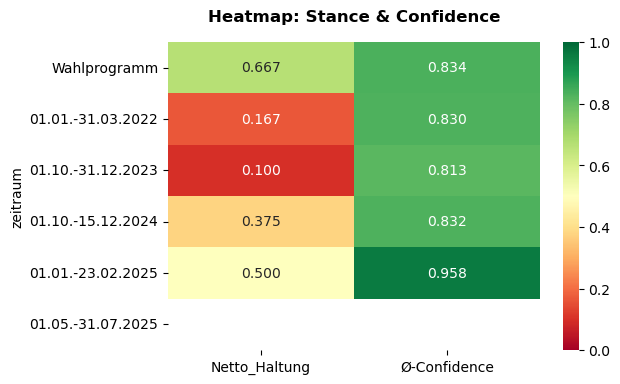

In [36]:

####### Auswertung für die FDP in der bürgergeld-Frage





client = OpenAI(api_key="sk-d-CKDAt5xmwp4kT5N7dMxA",base_url="https://hub.ki.fh-swf.de/v1")

# 1. Das präzise Schema für die Einzeltext-Klassifikation
class StanceAnalysis(BaseModel):
    stance: Literal["FAVOR", "AGAINST", "NEUTRAL", "IRRELEVANT"] = Field(
        description=(
            "The final overall stance toward the target topic. "
            "'FAVOR': Clearly supportive. "
            "'AGAINST': Clearly opposing. "
            "'NEUTRAL': Discusses the topic but takes a balanced, diplomatic, or non-judgmental stance. "
            "'IRRELEVANT': Does not mention or discuss the target topic at all."
        )
    )
    confidence_favor: float = Field(description="Confidence score for 'FAVOR' (0.0 to 1.0).")
    confidence_against: float = Field(description="Confidence score for 'AGAINST' (0.0 to 1.0).")
    confidence_neutral: float = Field(description="Confidence score for 'NEUTRAL' (0.0 to 1.0).")
    confidence_irrelevant: float = Field(description="Confidence score for 'IRRELEVANT' (0.0 to 1.0).")
    explanation: str = Field(description="A brief, one-sentence explanation of the stance classification.")

# 2. Zielthema als klare These definieren
target_topic = "Wir wollen das Bürgergeld abschaffen."

# --- SCHRITT A: DataFrame "aufbrechen" (Explode) ---
# Wir erstellen eine Kopie, damit Ihr Original-DataFrame unverändert bleibt
# df_exploded = grouped_documents_ukraine_fdp.copy()
df_exploded = grouped_documents_bürgergeld_fdp.copy()

# Jedes einzelne Segment in der Liste bekommt nun eine eigene Zeile im DataFrame
df_exploded = df_exploded.explode('document').reset_index(drop=True)

# Listen zum Speichern der Ergebnisse initialisieren
stances = []
confidences = []
explanations = []

# 3. Schleife über alle EINZELNEN Segmente
print(f"Starte Analyse von insgesamt {len(df_exploded)} Textsegmenten...")

for index, row in df_exploded.iterrows():
    text_to_analyze = row['document']
    
    # Überspringe leere Segmente, falls vorhanden
    if pd.isna(text_to_analyze) or str(text_to_analyze).strip() == "":
        stances.append("IRRELEVANT")
        confidences.append(1.0)
        explanations.append("Empty text segment.")
        continue

    prompt = f"""Analyze the stance of the following short text segment toward the target topic.
Target Topic: {target_topic}
Text: {text_to_analyze}"""

    # API-Aufruf für jedes einzelne Segment mit strukturiertem Output (Structured Outputs)
    try:
        response = client.beta.chat.completions.parse(
            model="gpt-5-nano",
            messages=[
                {"role": "system", "content": "Du bist ein präzises, politikwissenschaftliches KI-System zur quantitativen Inhaltsanalyse. Deine Aufgabe ist es, Wahlprogramme und Bundestagsreden bezüglich ihrer Haltung zu analysieren.\
                                    Gibt das Ergebnis AUSSCHLIESSLICH als valides JSON-Objekt aus.\
                                    WICHTIG: achte auf Ironie, Sarkasmus und vage Aussagen"},
                {"role": "user", "content": prompt}
            ],
            response_format=StanceAnalysis,
            reasoning_effort="medium",
            seed=42
        )        
        
        # Extraktion der strukturierten Antwort
        result = response.choices[0].message.parsed
        
        # Werte in die Listen speichern
        stances.append(result.stance)

        # Speichert die Konfidenz basierend auf der gewählten Klasse
        if result.stance == "FAVOR":
            confidences.append(result.confidence_favor)
        elif result.stance == "AGAINST":
            confidences.append(result.confidence_against)
        elif result.stance == "NEUTRAL":
            confidences.append(result.confidence_neutral)
        elif result.stance == "IRRELEVANT":
            confidences.append(result.confidence_irrelevant)
        else:
            # Sicherheitsnetz für unvorhergesehene Fälle
            confidences.append(0.0)
    
        explanations.append(result.explanation)
        
    except Exception as e:
        print(f"Fehler bei Index {index}: {e}")
        stances.append("IRRELEVANT")
        confidences.append(0.0)
        explanations.append(f"API Error: {str(e)}")

# 4. Ergebnisse an das "aufgebrochene" DataFrame anhängen
df_exploded['stance'] = stances
df_exploded['confidence'] = confidences
df_exploded['explanation'] = explanations

print("Analyse abgeschlossen!")

# --- SCHRITT C: Aggregation (Optional) ---
# Falls Sie die Ergebnisse wieder auf die ursprüngliche Zeilenebene (pro Zeitraum/Partei) bringen möchten:

CONFIDENCE_THRESHOLD = 0.60

# 2. Flag auf Segment-Ebene setzen (True/1 wenn unsicher, False/0 wenn sicher)
df_exploded['is_low_confidence'] = df_exploded['confidence'] < CONFIDENCE_THRESHOLD

# 3. Aggregation durchführen
df_aggregated_ukraine = df_exploded.groupby(['partei', 'zeitraum']).agg(
    Anzahl_Segmente=('document', 'count'),
    Anzahl_positiv=('stance', lambda x: (x == 'FAVOR').sum()),
    Anzahl_negativ=('stance', lambda x: (x == 'AGAINST').sum()),
    Anzahl_neutral_echt=('stance', lambda x: (x == 'NEUTRAL').sum()),
    Anzahl_irrelevant=('stance', lambda x: (x == 'IRRELEVANT').sum()),
    Durchschnitts_Confidence=('confidence', 'mean'),
    # HIER NEU: Zählt alle Segmente, bei denen die Confidence unter dem Schwellenwert lag
    Anzahl_Low_Confidence=('is_low_confidence', 'sum')
).reset_index()

# 4. Optional, aber dringend empfohlen für die Masterarbeit: Prozentualen Anteil berechnen
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = (df_aggregated_ukraine['Anzahl_Low_Confidence'] / df_aggregated_ukraine['Anzahl_Segmente']) * 100

# Kosmetische Rundung für eine saubere Tabelle
df_aggregated_ukraine['Durchschnitts_Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence_%'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# 1. Netto-Haltungs-Score berechnen (0 bis +1.0)
# -> 1. Schritt: Summe der relevanten Segmente berechnen (ohne das Rauschen von IRRELEVANT)
df_aggregated_ukraine['Anzahl_relevant'] = (
    df_aggregated_ukraine['Anzahl_positiv'] + 
    df_aggregated_ukraine['Anzahl_negativ'] + 
    df_aggregated_ukraine['Anzahl_neutral_echt']
)

# -> 2. Schritt: Netto-Haltung berechnen
df_aggregated_ukraine['Netto_Haltung'] = (
    (df_aggregated_ukraine['Anzahl_positiv'] * 1.0) + 
    (df_aggregated_ukraine['Anzahl_neutral_echt'] * 0.5) +
    (df_aggregated_ukraine['Anzahl_negativ'] * 0.0)
) / df_aggregated_ukraine['Anzahl_relevant']

# 2. Anteil des Zeitraums an den Gesamtsegmenten der jeweiligen Partei (in %)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine.groupby('partei')['Anzahl_Segmente'].transform(lambda x: (x / x.sum()) * 100)

# 3. Kosmetische Rundung für die Tabelle in der Masterarbeit
df_aggregated_ukraine['Netto_Haltung'] = df_aggregated_ukraine['Netto_Haltung'].round(3)
df_aggregated_ukraine['Anteil an Gesamt in %'] = df_aggregated_ukraine['Anteil an Gesamt in %'].round(1)

# Hier weisen wir die Rundung direkt der Spalte zu, die wir später in der Liste nutzen
df_aggregated_ukraine['Ø-Confidence'] = df_aggregated_ukraine['Durchschnitts_Confidence'].round(3)
df_aggregated_ukraine['Anteil_Low_Confidence in %'] = df_aggregated_ukraine['Anteil_Low_Confidence_%'].round(1)

# KORREKTUR: Spaltennamen exakt an die Aggregations-Ergebnisse angepasst
spalten_ordnung = [
    'partei', 'zeitraum', 'Anzahl_Segmente', 'Anteil an Gesamt in %',
    'Anzahl_positiv', 'Anzahl_negativ', 'Anzahl_neutral_echt', 'Anzahl_irrelevant', 
    'Netto_Haltung', 'Ø-Confidence', 
    'Anzahl_Low_Confidence', 'Anteil_Low_Confidence in %'
]
df_aggregated_ukraine_final = df_aggregated_ukraine[spalten_ordnung]

# CSV-Export
df_aggregated_ukraine_final.to_csv('ergebnisse_bürgergeld_fdp.csv', sep=';', index=False, encoding='utf-8-sig')

latex_code = df_aggregated_ukraine_final.to_latex(index=False, caption='Analyse der Bürgergeld-Stance (FDP)', label='tab:meine_tabelle')
with open('ergebnisse_bürgergeld_fdp.tex', 'w') as f:
    f.write(latex_code)

# 1. Daten für die Heatmap vorbereiten
pivot_data = df_aggregated_ukraine_final.set_index('zeitraum')[['Netto_Haltung', 'Ø-Confidence']]

# 2. Eine neue Matplotlib-Figur erstellen, um die Größe und den Hintergrund zu definieren
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# 3. Heatmap zeichnen (ax=ax stellt sicher, dass sie in unserer Figur landet)
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5, fmt=".3f", ax=ax)

# 4. Optische Feinschliffe (Titel hinzufügen und Achsen-Labels lesbar machen)
plt.title('Heatmap: Stance & Confidence', fontweight='bold', pad=15)
plt.yticks(rotation=0) # Sorgt dafür, dass die Datumsangaben links gerade stehen

# 5. Als scharfes JPG abspeichern
# 'bbox_inches="tight"' verhindert, dass die Datumsbeschriftungen am Rand abgeschnitten werden
plt.savefig('ergebnisse_bürgergeld_fdp_heatmap.jpg', dpi=200, bbox_inches='tight')

# 6. Plot im Notebook/Skript schließen, um Speicher zu sparen
plt.show()

In [42]:
# GESAMTCHART für alle Parteien

In [43]:
# Ergebnisse laden
df_fdp = pd.read_csv('ergebnisse_bürgergeld_fdp.csv', sep=';')
df_gruene = pd.read_csv('ergebnisse_bürgergeld_grüne.csv', sep=';')
df_linke = pd.read_csv('ergebnisse_bürgergeld_linke.csv', sep=';')
df_afd = pd.read_csv('ergebnisse_bürgergeld_afd.csv', sep=';')
df_spd = pd.read_csv('ergebnisse_bürgergeld_spd.csv', sep=';')
df_cdu = pd.read_csv('ergebnisse_bürgergeld_cdu.csv', sep=';')

In [44]:
# alle DataFrames in einer Liste sammeln
dfs = [df_fdp, df_gruene, df_linke, df_afd, df_spd, df_cdu]

# 3. Zu einem Gesamt-DataFrame verknüpfen
df_gesamt = pd.concat(dfs, ignore_index=True)
df_gesamt

,partei,zeitraum,Anzahl_Segmente,Anteil an Gesamt in %,Anzahl_positiv,Anzahl_negativ,Anzahl_neutral_echt,Anzahl_irrelevant,Netto_Haltung,Ø-Confidence,Anzahl_Low_Confidence,Anteil_Low_Confidence in %
0,FDP,Wahlprogramm,19,20.9,4.0,2.0,0.0,13.0,0.667,0.834,0,0.0
1,FDP,01.01.-31.03.2022,22,24.2,0.0,2.0,1.0,19.0,0.167,0.830,0,0.0
2,FDP,01.10.-31.12.2023,22,24.2,0.0,4.0,1.0,17.0,0.100,0.813,0,0.0
3,FDP,01.10.-15.12.2024,24,26.4,1.0,2.0,1.0,20.0,0.375,0.832,0,0.0
4,FDP,01.01.-23.02.2025,4,4.4,0.0,0.0,1.0,3.0,0.500,0.958,0,0.0
5,FDP,01.05.-31.07.2025,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
6,Grüne,Wahlprogramm,56,35.2,1.0,4.0,1.0,50.0,0.250,0.850,0,0.0
7,Grüne,01.01.-31.03.2022,16,10.1,0.0,5.0,1.0,10.0,0.083,0.828,0,0.0
8,Grüne,01.10.-31.12.2023,38,23.9,1.0,10.0,0.0,27.0,0.091,0.854,0,0.0
9,Grüne,01.10.-15.12.2024,21,13.2,1.0,3.0,2.0,15.0,0.333,0.863,0,0.0


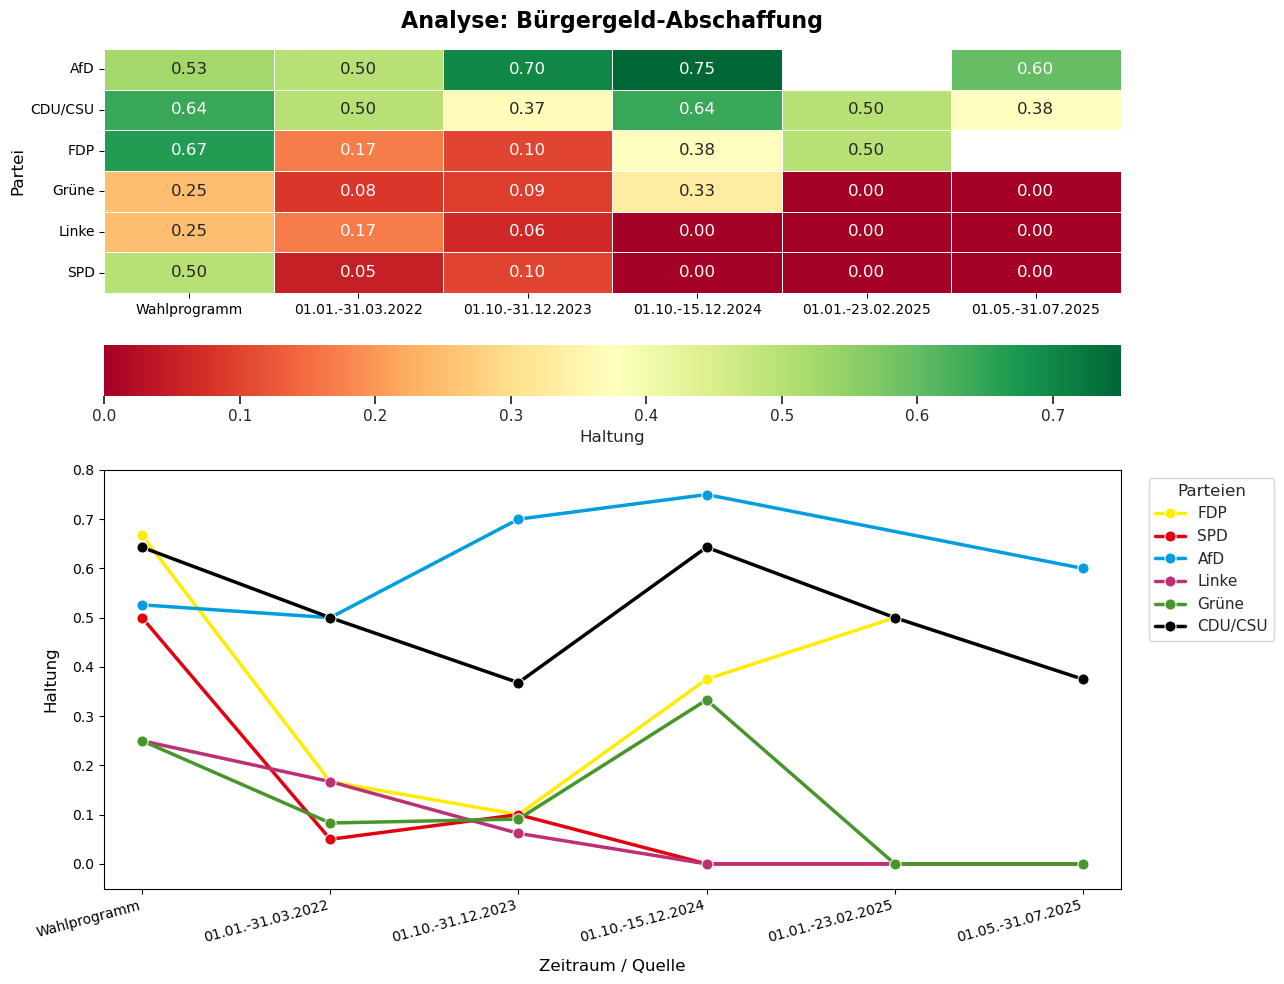

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# 1. DATEN BEREINIGEN & CHRONOLOGIE DEFINIEREN
# ==========================================
df_plot = df_gesamt.dropna(subset=['Netto_Haltung']).copy()

# Hier legen wir die exakte chronologische Reihenfolge fest (wie in Ihrer X-Achse unten)
zeitraum_reihenfolge = [
    'Wahlprogramm', 
    '01.01.-31.03.2022', 
    '01.10.-31.12.2023', 
    '01.10.-15.12.2024', 
    '01.01.-23.02.2025', 
    '01.05.-31.07.2025'
]

# Die Spalte 'zeitraum' in eine feste Kategorie umwandeln und danach sortieren
df_plot['zeitraum'] = pd.Categorical(df_plot['zeitraum'], categories=zeitraum_reihenfolge, ordered=True)
df_plot = df_plot.sort_values('zeitraum')

# ==========================================
# 2. MATRIX FÜR DIE HEATMAP ERSTELLEN
# ==========================================
# Durch die obige Categorical-Umwandlung ist die Heatmap nun AUTOMATISCH richtig sortiert!
df_heatmap = df_plot.pivot(index='partei', columns='zeitraum', values='Netto_Haltung')

# Optionale Sortierung der Parteien von oben nach unten beibehalten
partei_reihenfolge = ['AfD', 'CDU/CSU', 'FDP', 'Grüne', 'Linke', 'SPD']
vorhandene_parteien = [p for p in partei_reihenfolge if p in df_heatmap.index]
df_heatmap = df_heatmap.reindex(vorhandene_parteien)

# 3. Farbedefinitionen festlegen
partei_farben = {
    'CDU/CSU': '#000000', 'SPD': '#E3000F', 'Grüne': '#46962B', 
    'FDP': '#FFED00', 'Linke': '#BE3075', 'AfD': '#009EE0'
}

# 4. Großgrafik mit 2 Subplots anlegen (Größenverhältnis 1 : 1.2)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10), gridspec_kw={'height_ratios': [1, 1.2]})
sns.set_theme(style="whitegrid")

# ==========================================
# TEIL 1: DIE HEATMAP (OBEN)
# ==========================================
# Wertgrenzen festlegen (Je nach Skala -1 bis 1 ODER 0 bis 1)
v_min, v_max = (df_plot['Netto_Haltung'].min(), df_plot['Netto_Haltung'].max())

sns.heatmap(
    df_heatmap, 
    ax=ax1,
    cmap='RdYlGn',            # Rot-Gelb-Grün Farbverlauf
    annot=True,               # Werte in den Kästchen anzeigen
    fmt=".2f",                # 2 Nachkommastellen
    linewidths=.5,            # Dünne Trennlinien zwischen Kästchen
    cbar_kws={'label': 'Haltung', 'orientation': 'horizontal', 'pad': 0.15},
    vmin=v_min, vmax=v_max
)
ax1.set_title('Analyse: Bürgergeld-Abschaffung', fontsize=16, pad=15, fontweight='bold')
ax1.set_xlabel('') # Oben kein X-Achsen-Label nötig, da identisch mit unten
ax1.set_ylabel('Partei', fontsize=12)

# ==========================================
# TEIL 2: DAS LINIEDIAGRAMM (UNTEN)
# ==========================================
sns.lineplot(
    data=df_plot, 
    x='zeitraum', 
    y='Netto_Haltung', 
    hue='partei', 
    marker='o', 
    markersize=8, 
    linewidth=2.5,
    palette=partei_farben,
    ax=ax2
)
ax2.set_xlabel('Zeitraum / Quelle', fontsize=12, labelpad=10)
ax2.set_ylabel('Haltung', fontsize=12, labelpad=10)
ax2.set_ylim(v_min - 0.05, v_max + 0.05)
ax2.set_xlim(-0.2, len(df_heatmap.columns) - 0.8) # Bündiger Abschluss der Ränder

# X-Achsen-Beschriftung bei Bedarf leicht rotieren
plt.sca(ax2)
plt.xticks(rotation=15, ha='right')

# Null-Linie als Orientierung einzeichnen (nur wenn Werte negativ werden können)
if v_min < 0:
    ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Legende für das Liniendiagramm platzieren
ax2.legend(title='Parteien', bbox_to_anchor=(1.02, 1), loc='upper left')

# ==========================================
# SPEICHERN & ANZEIGEN
# ==========================================
plt.tight_layout()
plt.savefig('bürgergeld_kombigrafik.jpg', dpi=300, bbox_inches='tight')
plt.show()


In [48]:
# ENDE